# Connect to google account

# Global Variables

In [1]:
import os
import numpy as np
import pandas as pd
import random
import torch


def reset_seeds(seed=42):
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)    # 파이썬 환경변수 시드 고정
  np.random.seed(seed)
  torch.manual_seed(seed) # cpu 연산 무작위 고정
  torch.cuda.manual_seed(seed) # gpu 연산 무작위 고정
  torch.backends.cudnn.deterministic = True  # cuda 라이브러리에서 Deterministic(결정론적)으로 예측하기 (예측에 대한 불확실성 제거 )


# Load Netflix Data

In [2]:
reset_seeds() # 랜덤고정

import easydict
args = easydict.EasyDict()
from sklearn.model_selection import train_test_split


# 1. 경로 및 파일 설정 (Args 클래스)
class Args:
    def __init__(self):
        self.default_path = 'C:/dev/project/SKN27-2nd-2TEAM/models/data/'

        # 넷플릭스 원본 데이터
        self.users_csv = self.default_path + 'users.csv'
        self.watch_csv = self.default_path + 'watch_history.csv'
        self.movies_csv = self.default_path + 'movies.csv'
        self.rec_logs_csv = self.default_path + 'recommendation_logs.csv'
        self.search_logs_csv = self.default_path + 'search_logs.csv'
        self.reviews_csv = self.default_path + 'reviews.csv'

        # 생성할 파일 경로
        self.train_csv = self.default_path + 'Netflix_train.csv'
        self.test_csv = self.default_path + 'Netflix_test.csv'
        self.submission_filename = 'Netflix_submission.csv'
        self.default_submission_csv = self.default_path + self.submission_filename
        self.save_results = self.default_path + 'Netflix_results.json'

args = Args()

# 2. 메인 데이터 로드 (Target인 churned가 포함된 users.csv)
user = pd.read_csv(args.users_csv).drop_duplicates()        # 'churned' 컬럼이 있다고 가정
watch = pd.read_csv(args.watch_csv).drop_duplicates()
movies = pd.read_csv(args.movies_csv).drop_duplicates()
rec_logs = pd.read_csv(args.rec_logs_csv).drop_duplicates()
search_logs = pd.read_csv(args.search_logs_csv).drop_duplicates()
reviews = pd.read_csv(args.reviews_csv).drop_duplicates()
Netflix_users = pd.read_csv(args.users_csv).drop_duplicates()

# 3. Target 변환 (Active -> Churned)
Netflix_users['is_churned'] = 1 - Netflix_users['is_active']
Netflix_users = Netflix_users.drop(columns=['is_active'])

# 데이터 분석을 위한 변수들
args.random_state = 21
args.results = []

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\296519677.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({


                                    comparison  total_users  changed_users  \
0                        core vs core + review        10000           1084   
1           core vs core + recommendation(all)        10000           2813   
2  core vs core + recommendation(clicked only)        10000            588   

   changed_ratio_%  delayed_users  delayed_ratio_%  median_delay_days  \
0            10.84           1084            10.84                 45   
1            28.13           2813            28.13                 43   
2             5.88            588             5.88                 42   

   mean_delay_days  p75_delay_days  p90_delay_days  max_delay_days  
0            61.66              88             139             356  
1            60.83              84             141             486  
2            60.69              89             138             430  
                           column  non_null_count  non_null_ratio_%
0                 last_watch_date           10000 

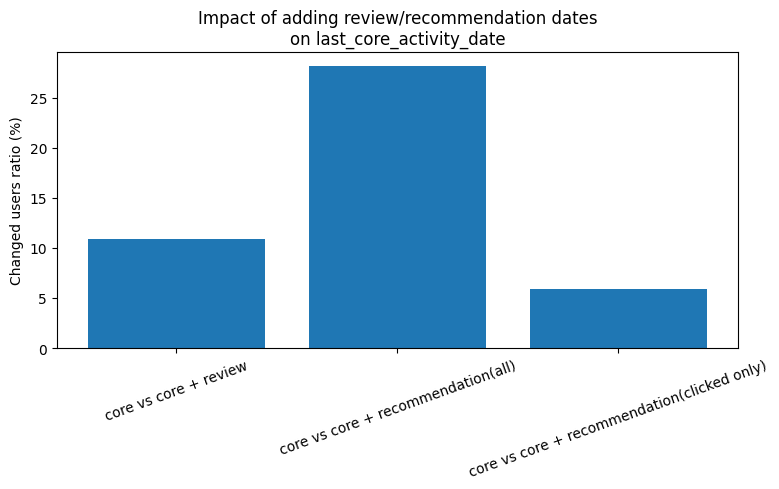

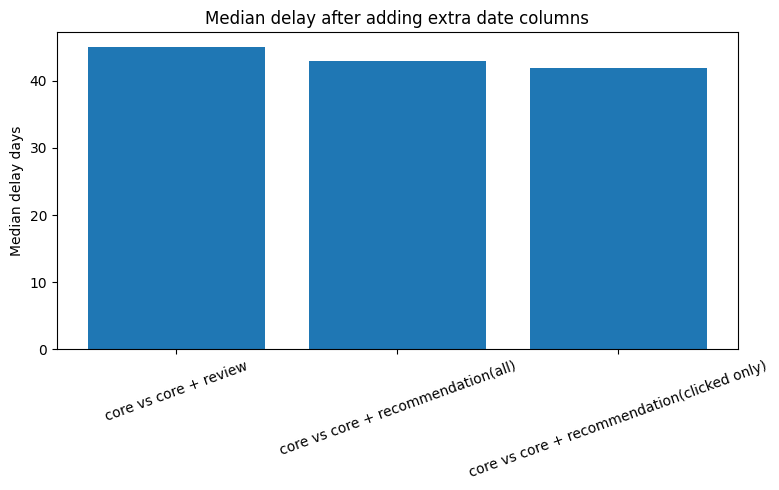

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 0. 날짜형 변환
# -------------------------------------------------
watch_tmp = watch[['user_id', 'watch_date']].copy()
search_tmp = search_logs[['user_id', 'search_date']].copy()
review_tmp = reviews[['user_id', 'review_date']].copy()
rec_tmp = rec_logs[['user_id', 'recommendation_date', 'was_clicked']].copy()

watch_tmp['watch_date'] = pd.to_datetime(watch_tmp['watch_date'], errors='coerce')
search_tmp['search_date'] = pd.to_datetime(search_tmp['search_date'], errors='coerce')
review_tmp['review_date'] = pd.to_datetime(review_tmp['review_date'], errors='coerce')
rec_tmp['recommendation_date'] = pd.to_datetime(rec_tmp['recommendation_date'], errors='coerce')

# recommendation 클릭 여부 0/1 변환
rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({
    True: 1, False: 0,
    'True': 1, 'False': 0,
    'true': 1, 'false': 0,
    1: 1, 0: 0
})
rec_tmp['was_clicked_num'] = pd.to_numeric(rec_tmp['was_clicked_num'], errors='coerce')


# -------------------------------------------------
# 1. user별 마지막 날짜 map 만들기
# -------------------------------------------------
last_watch_date_map = watch_tmp.groupby('user_id')['watch_date'].max().to_dict()
last_search_date_map = search_tmp.groupby('user_id')['search_date'].max().to_dict()
last_review_date_map = review_tmp.groupby('user_id')['review_date'].max().to_dict()
last_recommendation_date_map = rec_tmp.groupby('user_id')['recommendation_date'].max().to_dict()

# 클릭한 recommendation만 따로
rec_clicked_tmp = rec_tmp[rec_tmp['was_clicked_num'] == 1].copy()
last_recommendation_click_date_map = (
    rec_clicked_tmp.groupby('user_id')['recommendation_date'].max().to_dict()
)


# -------------------------------------------------
# 2. 비교용 user-level 데이터프레임 만들기
# user는 기본 user 테이블
# -------------------------------------------------
compare_df = user[['user_id']].copy()

compare_df['last_watch_date'] = compare_df['user_id'].map(last_watch_date_map)
compare_df['last_search_date'] = compare_df['user_id'].map(last_search_date_map)
compare_df['last_review_date'] = compare_df['user_id'].map(last_review_date_map)
compare_df['last_recommendation_date'] = compare_df['user_id'].map(last_recommendation_date_map)
compare_df['last_recommendation_click_date'] = compare_df['user_id'].map(last_recommendation_click_date_map)

date_cols = [
    'last_watch_date',
    'last_search_date',
    'last_review_date',
    'last_recommendation_date',
    'last_recommendation_click_date'
]

for col in date_cols:
    compare_df[col] = pd.to_datetime(compare_df[col], errors='coerce')


# -------------------------------------------------
# 3. 핵심 기준 날짜 만들기
# "사실상 콘텐츠 소비가 끊긴 날"의 core 기준
# = watch + search
# -------------------------------------------------
compare_df['last_core_activity_date'] = compare_df[['last_watch_date', 'last_search_date']].max(axis=1)

# review 포함
compare_df['last_core_plus_review_date'] = compare_df[
    ['last_watch_date', 'last_search_date', 'last_review_date']
].max(axis=1)

# recommendation 전체 포함
compare_df['last_core_plus_recommendation_date'] = compare_df[
    ['last_watch_date', 'last_search_date', 'last_recommendation_date']
].max(axis=1)

# recommendation 클릭만 포함
compare_df['last_core_plus_recommendation_click_date'] = compare_df[
    ['last_watch_date', 'last_search_date', 'last_recommendation_click_date']
].max(axis=1)


# -------------------------------------------------
# 4. 영향도 비교 함수
# -------------------------------------------------
def summarize_impact(df, base_col, compare_col, label):
    delta_days = (df[compare_col] - df[base_col]).dt.days

    changed_mask = delta_days.notna() & (delta_days != 0)
    delayed_mask = delta_days > 0

    result = {
        'comparison': label,
        'total_users': len(df),
        'changed_users': int(changed_mask.sum()),
        'changed_ratio_%': round(changed_mask.mean() * 100, 2),
        'delayed_users': int(delayed_mask.sum()),
        'delayed_ratio_%': round(delayed_mask.mean() * 100, 2),
        'median_delay_days': int(delta_days[delayed_mask].median()) if delayed_mask.sum() > 0 else 0,
        'mean_delay_days': round(delta_days[delayed_mask].mean(), 2) if delayed_mask.sum() > 0 else 0,
        'p75_delay_days': int(delta_days[delayed_mask].quantile(0.75)) if delayed_mask.sum() > 0 else 0,
        'p90_delay_days': int(delta_days[delayed_mask].quantile(0.90)) if delayed_mask.sum() > 0 else 0,
        'max_delay_days': int(delta_days[delayed_mask].max()) if delayed_mask.sum() > 0 else 0,
    }
    return result


# -------------------------------------------------
# 5. review / recommendation 영향도 요약
# -------------------------------------------------
summary_list = []

summary_list.append(
    summarize_impact(
        compare_df,
        'last_core_activity_date',
        'last_core_plus_review_date',
        'core vs core + review'
    )
)

summary_list.append(
    summarize_impact(
        compare_df,
        'last_core_activity_date',
        'last_core_plus_recommendation_date',
        'core vs core + recommendation(all)'
    )
)

summary_list.append(
    summarize_impact(
        compare_df,
        'last_core_activity_date',
        'last_core_plus_recommendation_click_date',
        'core vs core + recommendation(clicked only)'
    )
)

summary_df = pd.DataFrame(summary_list)
print(summary_df)


# -------------------------------------------------
# 6. 커버리지 확인
# 각 날짜 컬럼이 실제로 얼마나 있는지
# -------------------------------------------------
coverage_df = pd.DataFrame({
    'column': [
        'last_watch_date',
        'last_search_date',
        'last_review_date',
        'last_recommendation_date',
        'last_recommendation_click_date',
        'last_core_activity_date'
    ],
    'non_null_count': [
        compare_df['last_watch_date'].notna().sum(),
        compare_df['last_search_date'].notna().sum(),
        compare_df['last_review_date'].notna().sum(),
        compare_df['last_recommendation_date'].notna().sum(),
        compare_df['last_recommendation_click_date'].notna().sum(),
        compare_df['last_core_activity_date'].notna().sum(),
    ]
})

coverage_df['non_null_ratio_%'] = round(coverage_df['non_null_count'] / len(compare_df) * 100, 2)
print(coverage_df)


# -------------------------------------------------
# 7. 발표용 그래프 1: 마지막 활동일이 바뀌는 유저 비율
# -------------------------------------------------
plot_df = summary_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df['comparison'], plot_df['changed_ratio_%'])
plt.ylabel('Changed users ratio (%)')
plt.title('Impact of adding review/recommendation dates\non last_core_activity_date')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 8. 발표용 그래프 2: 바뀐 유저들 기준 지연 일수 중앙값
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(plot_df['comparison'], plot_df['median_delay_days'])
plt.ylabel('Median delay days')
plt.title('Median delay after adding extra date columns')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# 위 그래프 뽑은 이유 : 
- review와 recommendation click 한 date 값들이 과연 얼마나 영향을 주는지 확인하기 위함! 

# 위 그래프의 해석 : 
- review와 recommendation click 한 date를 집어 넣어도 change 되는 비율이 적음!! -> 영향이 크게 없으니 제외!

=== Non-churn users return gap summary ===
count: 97012
mean: 53.91
median: 38.00
p75: 75.00
p90: 124.00
p95: 161.00
p99: 245.00
max: 537

=== Gap summary table ===
   metric     value
0   count  97012.00
1    mean     53.91
2  median     38.00
3     p75     75.00
4     p90    124.00
5     p95    161.00
6     p99    245.00
7     max    537.00


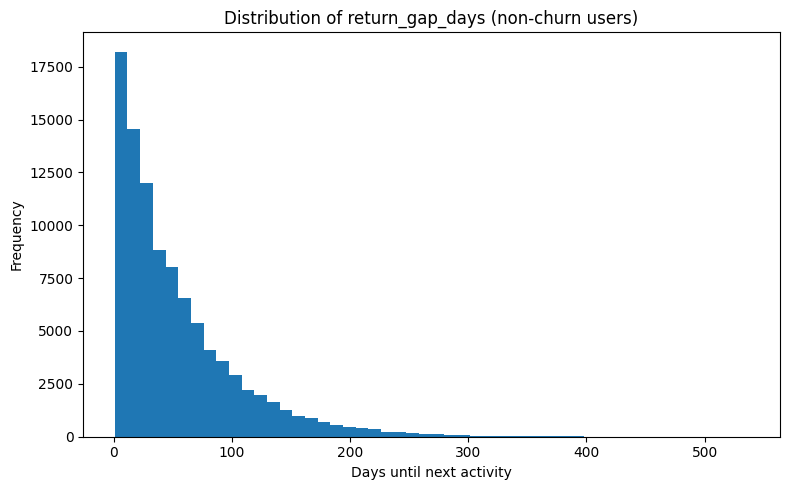

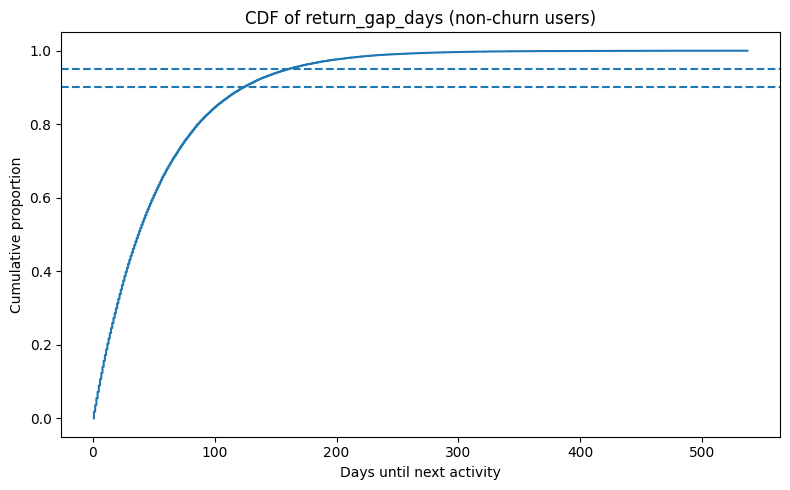

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 0. non-churn 유저 정의
# -------------------------------------------------
non_churn_user_ids = user.loc[user['is_active'] == True, 'user_id'].unique()

# -------------------------------------------------
# 1. activity 로그 만들기
# 기준: watch_date + search_date
# 같은 날 여러 활동은 1일 1활동으로 처리
# -------------------------------------------------
watch_activity = watch[['user_id', 'watch_date']].copy()
watch_activity = watch_activity.rename(columns={'watch_date': 'activity_date'})
watch_activity['activity_date'] = pd.to_datetime(watch_activity['activity_date'], errors='coerce')

search_activity = search_logs[['user_id', 'search_date']].copy()
search_activity = search_activity.rename(columns={'search_date': 'activity_date'})
search_activity['activity_date'] = pd.to_datetime(search_activity['activity_date'], errors='coerce')

activity_log = pd.concat([watch_activity, search_activity], ignore_index=True)

# non-churn 유저만 남기기
activity_log = activity_log[activity_log['user_id'].isin(non_churn_user_ids)].copy()

# 날짜 없는 행 제거
activity_log = activity_log.dropna(subset=['activity_date'])

# 날짜만 남기기 (시간 제거)
activity_log['activity_date'] = activity_log['activity_date'].dt.normalize()

# 같은 유저가 같은 날 여러 번 활동한 경우 1번으로 처리
activity_log = activity_log.drop_duplicates(subset=['user_id', 'activity_date'])

# -------------------------------------------------
# 2. 유저별 활동일 정렬 후 다음 활동일까지 gap 계산
# -------------------------------------------------
activity_log = activity_log.sort_values(['user_id', 'activity_date']).copy()

activity_log['next_activity_date'] = activity_log.groupby('user_id')['activity_date'].shift(-1)

activity_log['return_gap_days'] = (
    activity_log['next_activity_date'] - activity_log['activity_date']
).dt.days

# 마지막 활동은 다음 활동이 없으므로 제외
gap_df = activity_log.dropna(subset=['return_gap_days']).copy()

# 혹시 이상치/음수 방지
gap_df = gap_df[gap_df['return_gap_days'] >= 0].copy()

# 정수형
gap_df['return_gap_days'] = gap_df['return_gap_days'].astype(int)

# -------------------------------------------------
# 3. 요약 통계
# -------------------------------------------------
gap_summary = {
    'count': len(gap_df),
    'mean': gap_df['return_gap_days'].mean(),
    'median': gap_df['return_gap_days'].median(),
    'p75': gap_df['return_gap_days'].quantile(0.75),
    'p90': gap_df['return_gap_days'].quantile(0.90),
    'p95': gap_df['return_gap_days'].quantile(0.95),
    'p99': gap_df['return_gap_days'].quantile(0.99),
    'max': gap_df['return_gap_days'].max()
}

print("=== Non-churn users return gap summary ===")
for k, v in gap_summary.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")

# -------------------------------------------------
# 4. 발표용 표
# -------------------------------------------------
gap_summary_df = pd.DataFrame({
    'metric': ['count', 'mean', 'median', 'p75', 'p90', 'p95', 'p99', 'max'],
    'value': [
        len(gap_df),
        round(gap_df['return_gap_days'].mean(), 2),
        round(gap_df['return_gap_days'].median(), 2),
        round(gap_df['return_gap_days'].quantile(0.75), 2),
        round(gap_df['return_gap_days'].quantile(0.90), 2),
        round(gap_df['return_gap_days'].quantile(0.95), 2),
        round(gap_df['return_gap_days'].quantile(0.99), 2),
        gap_df['return_gap_days'].max()
    ]
})

print("\n=== Gap summary table ===")
print(gap_summary_df)

# -------------------------------------------------
# 5. 히스토그램
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(gap_df['return_gap_days'], bins=50)
plt.title('Distribution of return_gap_days (non-churn users)')
plt.xlabel('Days until next activity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 6. 누적분포(CDF) 그래프
# 발표용으로 threshold 설명할 때 좋음
# -------------------------------------------------
sorted_gaps = np.sort(gap_df['return_gap_days'].values)
cdf = np.arange(1, len(sorted_gaps) + 1) / len(sorted_gaps)

plt.figure(figsize=(8, 5))
plt.plot(sorted_gaps, cdf)
plt.axhline(0.90, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.title('CDF of return_gap_days (non-churn users)')
plt.xlabel('Days until next activity')
plt.ylabel('Cumulative proportion')
plt.tight_layout()
plt.show()

# 위 그래프 뽑은 이유 : 
- Non-churn users return gap 들을 확인해서 churn users의 gap을 정의하여 churn user의 churn date를 유추하기 위함

# 위 그래프의 해석 : 
-  median(50%의 기존 유저)는 38일 안에 복귀함 -> 이 기준으로 churn user의 마지막 반응한 날짜에 더해 chrun date를 가정함

In [5]:
from something import NetflixFeatureBuilder

builder = NetflixFeatureBuilder(
    user=user,
    watch=watch,
    reviews=reviews,
    rec_logs=rec_logs,
    search_logs=search_logs,
    movies=movies
)

print(hasattr(builder, 'new_user'))  # True 나와야 정상

True


In [6]:
builder.add_last_activity_date()
new_user = builder.get_data()
new_user.head()

c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:364: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({


,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,monthly_spend,primary_device,household_size,created_at,last_watch_date,last_search_date,last_review_date,last_recommendation_click_date,last_activity_date,last_core_activity_date
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,36.06,Laptop,1.0,2023-04-01 14:40:50.540242,2025-10-30,2024-12-29,2024-01-09,NaT,2025-10-30,2025-10-30
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,14.59,Desktop,2.0,2024-10-10 15:39:11.030515,2025-11-28,2025-12-08,2025-09-12,NaT,2025-12-08,2025-12-08
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,11.71,Desktop,3.0,2024-06-29 14:27:49.560875,2025-06-24,NaT,2024-04-17,2025-04-13,2025-06-24,2025-06-24
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,28.56,Laptop,2.0,2023-04-11 01:01:59.614841,2025-12-29,2025-12-29,2025-03-12,NaT,2025-12-29,2025-12-29
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,9.54,Desktop,6.0,2025-04-12 19:59:30.137806,2025-09-19,2025-09-29,2025-09-26,NaT,2025-09-29,2025-09-29


In [7]:
builder.add_estimated_churn_date_p50()
builder.add_final_estimated_churn_date()

new_user = builder.get_data()
new_user.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,created_at,last_watch_date,last_search_date,last_review_date,last_recommendation_click_date,last_activity_date,last_core_activity_date,estimated_churn_date_p50,is_p50_estimate_valid,final_estimated_churn_date
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,2023-04-01 14:40:50.540242,2025-10-30,2024-12-29,2024-01-09,NaT,2025-10-30,2025-10-30,2025-12-07,True,NaT
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,2024-10-10 15:39:11.030515,2025-11-28,2025-12-08,2025-09-12,NaT,2025-12-08,2025-12-08,2026-01-15,True,NaT
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,2024-06-29 14:27:49.560875,2025-06-24,NaT,2024-04-17,2025-04-13,2025-06-24,2025-06-24,2025-08-01,True,2025-08-01
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,2023-04-11 01:01:59.614841,2025-12-29,2025-12-29,2025-03-12,NaT,2025-12-29,2025-12-29,2026-02-05,True,NaT
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,2025-04-12 19:59:30.137806,2025-09-19,2025-09-29,2025-09-26,NaT,2025-09-29,2025-09-29,2025-11-06,True,NaT


In [8]:
OBS_END_DATE = pd.to_datetime('2025-12-31')

new_user['final_estimated_churn_date'] = pd.to_datetime(
    new_user['final_estimated_churn_date'],
    errors='coerce'
)

new_user.loc[
    new_user['final_estimated_churn_date'] > OBS_END_DATE,
    'final_estimated_churn_date'
] = OBS_END_DATE

# 보기 좋게 date만 남기기
new_user['final_estimated_churn_date'] = new_user['final_estimated_churn_date'].dt.date

In [9]:
import pandas as pd

# -------------------------------------------------
# final_estimated_churn_date를 날짜형으로 변환
# -------------------------------------------------
new_user['final_estimated_churn_date'] = pd.to_datetime(
    new_user['final_estimated_churn_date'],
    errors='coerce'
)

# -------------------------------------------------
# compare_group만 추가
# - Target: 2025-11
# - Base: 2025-08 ~ 2025-10
# - active 유저 / 다른 월은 None
# -------------------------------------------------
new_user['compare_group'] = None

# 날짜에서 월 문자열을 "임시로" 계산
estimated_month = new_user['final_estimated_churn_date'].dt.to_period('M').astype(str)

# 2025-11 churn 유저
new_user.loc[
    (new_user['is_active'] == False) &
    (estimated_month == '2025-11'),
    'compare_group'
] = 'Target (2025-11)'

# 2025-08 ~ 2025-10 churn 유저
new_user.loc[
    (new_user['is_active'] == False) &
    (estimated_month.isin(['2025-08', '2025-09', '2025-10'])),
    'compare_group'
] = 'Base (2025-08~10)'

new_user.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,last_watch_date,last_search_date,last_review_date,last_recommendation_click_date,last_activity_date,last_core_activity_date,estimated_churn_date_p50,is_p50_estimate_valid,final_estimated_churn_date,compare_group
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,2025-10-30,2024-12-29,2024-01-09,NaT,2025-10-30,2025-10-30,2025-12-07,True,NaT,None
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,2025-11-28,2025-12-08,2025-09-12,NaT,2025-12-08,2025-12-08,2026-01-15,True,NaT,None
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,2025-06-24,NaT,2024-04-17,2025-04-13,2025-06-24,2025-06-24,2025-08-01,True,2025-08-01,Base (2025-08~10)
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,2025-12-29,2025-12-29,2025-03-12,NaT,2025-12-29,2025-12-29,2026-02-05,True,NaT,None
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,2025-09-19,2025-09-29,2025-09-26,NaT,2025-09-29,2025-09-29,2025-11-06,True,NaT,None


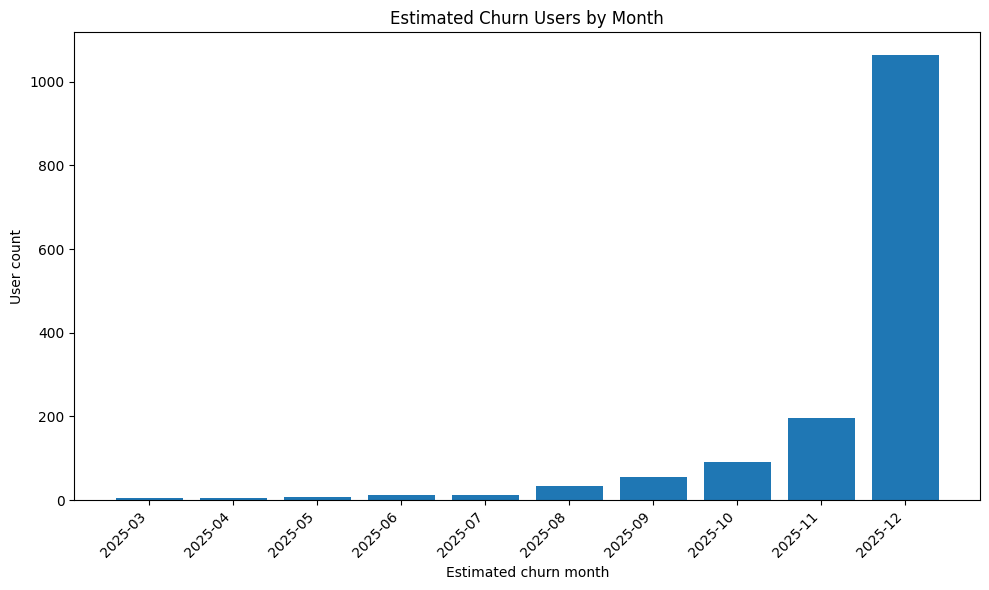

,estimated_churn_month,estimated_churn_user_count
0,2025-03,4
1,2025-04,4
2,2025-05,7
3,2025-06,12
4,2025-07,12
5,2025-08,33
6,2025-09,56
7,2025-10,92
8,2025-11,196
9,2025-12,1065


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# 1) new_user에서 필요한 컬럼만 임시로 가져오기
# ------------------------------------------
monthly_churn_source = new_user[['user_id', 'is_active', 'final_estimated_churn_date']].copy()

# ------------------------------------------
# 2) 날짜형으로 변환
# ------------------------------------------
monthly_churn_source['final_estimated_churn_date'] = pd.to_datetime(
    monthly_churn_source['final_estimated_churn_date'],
    errors='coerce'
)

# ------------------------------------------
# 3) churn 유저만 사용
#    - is_active == False
#    - estimated churn date가 있는 유저만 사용
# ------------------------------------------
monthly_churn_source = monthly_churn_source[
    (monthly_churn_source['is_active'] == False) &
    (monthly_churn_source['final_estimated_churn_date'].notna())
].copy()

# ------------------------------------------
# 4) 월 단위 문자열을 임시로 생성
#    예: 2025-11
#    new_user에는 저장하지 않음
# ------------------------------------------
monthly_churn_source['estimated_churn_month'] = (
    monthly_churn_source['final_estimated_churn_date']
    .dt.to_period('M')
    .astype(str)
)

# ------------------------------------------
# 5) 월별 estimated churn user 수 집계
# ------------------------------------------
monthly_churn_count = (
    monthly_churn_source
    .groupby('estimated_churn_month')['user_id']
    .count()
    .reset_index(name='estimated_churn_user_count')
    .sort_values('estimated_churn_month')
)

# ------------------------------------------
# 6) 그래프
# ------------------------------------------
plt.figure(figsize=(10, 6))
plt.bar(
    monthly_churn_count['estimated_churn_month'],
    monthly_churn_count['estimated_churn_user_count']
)

plt.xlabel('Estimated churn month')
plt.ylabel('User count')
plt.title('Estimated Churn Users by Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 표도 같이 확인
monthly_churn_count

# 위 그래프 뽑은 이유 : 
- churn date를 가지고 월별로 얼마나 churn 했는지 확인 필요

# 위 그래프의 해석 : 
- 월별로 churn 하는 user 수가 증가함        
- 12월의 경우 뭉개지는 데이터라 무시 (+38일 한 데이터가 26년 이후면 12월에 나간걸로 처리를 하면서 데이터가 겹침)

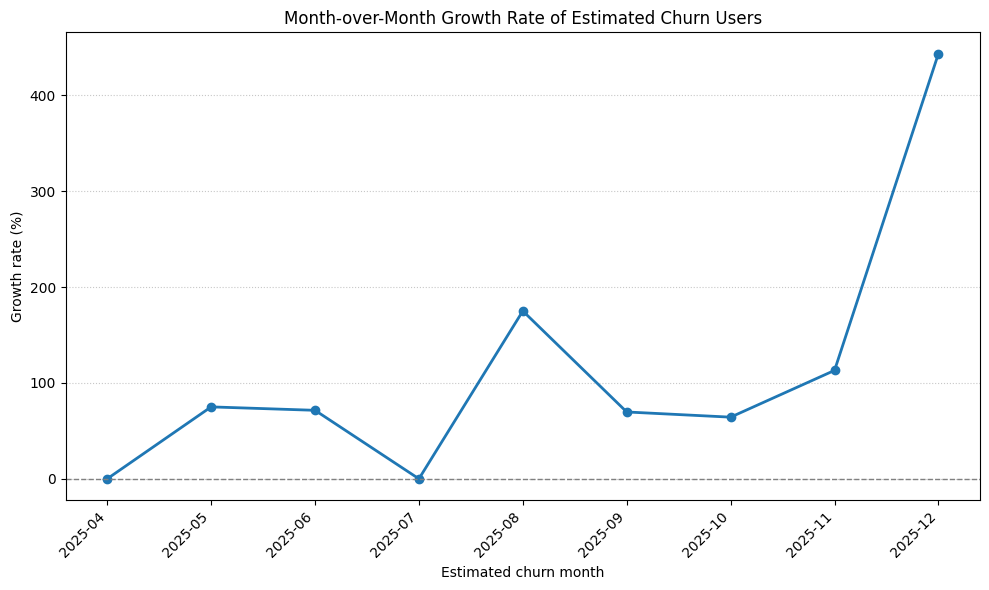

,estimated_churn_month,estimated_churn_user_count,growth_rate_pct
0,2025-03,4,NaN
1,2025-04,4,0.000000
2,2025-05,7,75.000000
3,2025-06,12,71.428571
4,2025-07,12,0.000000
5,2025-08,33,175.000000
6,2025-09,56,69.696970
7,2025-10,92,64.285714
8,2025-11,196,113.043478
9,2025-12,1065,443.367347


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------
# 1) 전월 대비 증가율(%) 계산
# ------------------------------------------
monthly_churn_growth = monthly_churn_count.copy()

monthly_churn_growth['growth_rate_pct'] = (
    monthly_churn_growth['estimated_churn_user_count']
    .pct_change() * 100
)

# ------------------------------------------
# 2) 그래프 (선 그래프로 변경)
# ------------------------------------------
plt.figure(figsize=(10, 6))

# plt.bar 대신 plt.plot을 사용합니다.
plt.plot(
    monthly_churn_growth['estimated_churn_month'],
    monthly_churn_growth['growth_rate_pct'],
    marker='o',           # 데이터 포인트 표시
    linestyle='-',        # 선 스타일
    linewidth=2,          # 선 두께
    color='#1f77b4'       # 선 색상
)

plt.xlabel('Estimated churn month')
plt.ylabel('Growth rate (%)')
plt.title('Month-over-Month Growth Rate of Estimated Churn Users')
plt.xticks(rotation=45, ha='right')

# 0을 기준으로 증가/감소를 쉽게 확인하기 위한 수평선
plt.axhline(0, color='gray', linewidth=1, linestyle='--')

# 수치 변화를 더 잘 보기 위해 그리드 추가 (선택 사항)
plt.grid(True, axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

monthly_churn_growth

# 위 그래프 뽑은 이유 : 
- churn date를 가지고 월별로 얼마나 증가했는지 비율을 보기 위함!! 증감율 확인이 필요!

# 위 그래프의 해석 : 
- 8월과 11월에 증가함!
- 8월의 경우 그 전달의 데이터들이 적어 11월 증가 데이터를 비교하는 것이 적절하다 판단!
- 9월 + 10월 vs 11월

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# [목적]
# new_user 전체에서
# "2025-11 estimated churn 유저"와
# "2025-09~10 estimated churn 유저"만 뽑아서
# 비교용 임시 데이터프레임(comparison_df)을 만든다.
#
# [주의]
# - new_user 자체는 수정하지 않음
# - comparison_df는 그래프 그리기 위한 임시 df
# -------------------------------------------------

# 1) 그래프 비교에 필요한 컬럼만 new_user에서 복사
#    user_id: 유저 수를 셀 때 필요
#    is_active: churn 유저만 고르기 위해 필요
#    final_estimated_churn_date: 이탈 추정 월 계산에 필요
#    subscription_plan / primary_device / country / age:
#    각각 비교 그래프에 필요한 기준 컬럼
comparison_df = new_user[
    ['user_id', 'is_active', 'final_estimated_churn_date',
     'subscription_plan', 'primary_device', 'country', 'age']
].copy()

# 2) final_estimated_churn_date를 datetime 형식으로 변환
#    문자열 상태면 month 추출이 불편하므로 먼저 날짜형으로 바꿔줌
comparison_df['final_estimated_churn_date'] = pd.to_datetime(
    comparison_df['final_estimated_churn_date'],
    errors='coerce'   # 날짜 변환이 안 되면 NaT 처리
)

# 3) churn 유저만 남김
#    여기서는 "왜 churn이 증가했는가?"를 볼 거라
#    active 유저는 비교 대상에서 제외
comparison_df = comparison_df[
    (comparison_df['is_active'] == False) &
    (comparison_df['final_estimated_churn_date'].notna())
].copy()

# 4) final_estimated_churn_date에서 월만 임시로 추출
#    예: 2025-11
#    new_user에는 저장하지 않고 comparison_df 안에서만 사용
estimated_month = (
    comparison_df['final_estimated_churn_date']
    .dt.to_period('M')
    .astype(str)
)

# 5) compare_group 컬럼 생성
#    우리가 비교하려는 두 그룹을 나눔
#    - Target: 2025-11 estimated churn 유저
#    - Base:   2025-09~10 estimated churn 유저
comparison_df['compare_group'] = None

# 6) 2025-11 유저는 Target 그룹으로 지정
comparison_df.loc[
    estimated_month == '2025-11',
    'compare_group'
] = 'Target (2025-11)'

# 7) 2025-09~10 유저는 Base 그룹으로 지정
comparison_df.loc[
    estimated_month.isin(['2025-09', '2025-10']),
    'compare_group'
] = 'Base (2025-09~10)'

# 8) Target / Base 둘 중 하나로 분류된 유저만 남김
#    다른 월(예: 8월, 12월)은 이번 비교에서 제외
comparison_df = comparison_df[
    comparison_df['compare_group'].notna()
].copy()

# 9) 확인
comparison_df.head()

,user_id,is_active,final_estimated_churn_date,subscription_plan,primary_device,country,age,compare_group
115,user_00116,False,2025-11-12,Standard,Tablet,USA,37.0,Target (2025-11)
139,user_00140,False,2025-09-20,Standard,Smart TV,USA,51.0,Base (2025-09~10)
145,user_00146,False,2025-11-03,Premium+,Gaming Console,USA,29.0,Target (2025-11)
182,user_00183,False,2025-11-29,Premium,Desktop,USA,22.0,Target (2025-11)
231,user_00232,False,2025-11-04,Premium,Gaming Console,USA,13.0,Target (2025-11)


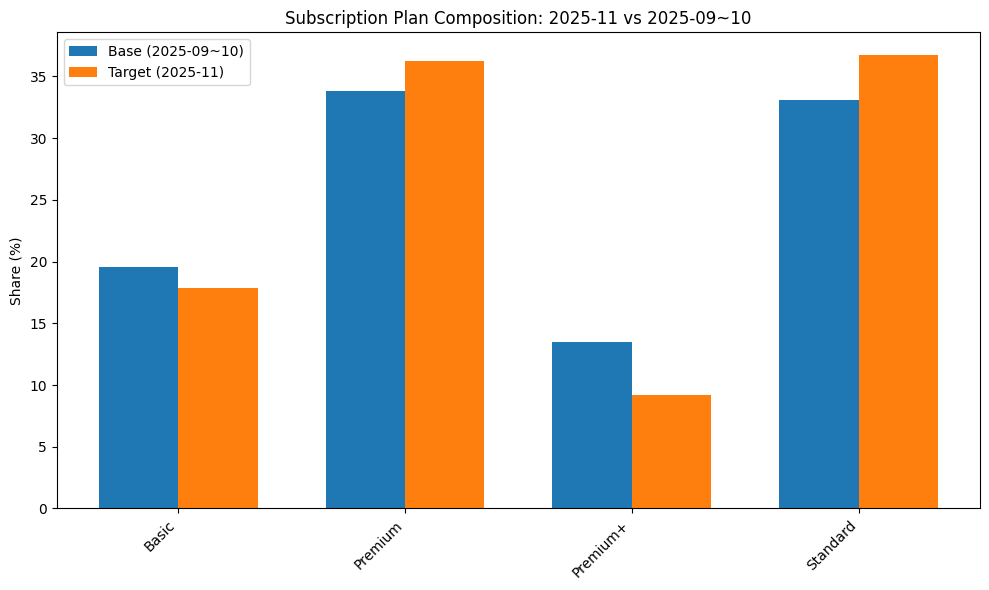

compare_group,Base (2025-09~10),Target (2025-11)
subscription_plan,,
Basic,0.195946,0.178571
Premium,0.337838,0.362245
Premium+,0.135135,0.091837
Standard,0.331081,0.367347


In [13]:
# -------------------------------------------------
# [목적]
# compare_group 별로 subscription_plan 구성비를 비교
#
# [해석]
# 예를 들어 Target(11월)에서 Premium 비중이 더 높다면,
# 11월 churn 증가가 Premium 사용자 쪽에서 상대적으로 더 많이 나타났다고 볼 수 있음
# -------------------------------------------------

# 1) compare_group + subscription_plan 조합별 유저 수 집계
#    예:
#    - Base (2025-09~10), Premium -> 몇 명?
#    - Target (2025-11), Basic -> 몇 명?
plan_plot = (
    comparison_df
    .groupby(['compare_group', 'subscription_plan'])['user_id']
    .count()
    .reset_index(name='user_count')
)

# 2) 각 그룹 내 비중(share) 계산
#    단순 count만 보면 그룹 크기가 달라서 비교가 어려움
#    그래서 각 compare_group 안에서 비율로 바꿈
plan_plot['share'] = (
    plan_plot['user_count']
    / plan_plot.groupby('compare_group')['user_count'].transform('sum')
)

# 3) 그래프 그리기 쉽게 pivot 형태로 변환
#    index   = subscription_plan
#    columns = compare_group
#    values  = share
#
#    결과 예:
#                     Base    Target
#      Basic          0.20    0.18
#      Premium        0.33    0.36
plan_pivot = plan_plot.pivot(
    index='subscription_plan',
    columns='compare_group',
    values='share'
).fillna(0)

# 4) 컬럼 순서 고정
#    항상 Base를 왼쪽, Target을 오른쪽에 두기 위함
plan_pivot = plan_pivot[['Base (2025-09~10)', 'Target (2025-11)']]

# 5) 막대 위치 계산
x = np.arange(len(plan_pivot))   # 구독 플랜 개수만큼 x축 좌표 생성
width = 0.35                     # 막대 너비

# 6) 그래프 생성
plt.figure(figsize=(10, 6))

# Base 그룹 막대
plt.bar(
    x - width/2,
    plan_pivot['Base (2025-09~10)'] * 100,   # 비율 -> %로 변환
    width=width,
    label='Base (2025-09~10)'
)

# Target 그룹 막대
plt.bar(
    x + width/2,
    plan_pivot['Target (2025-11)'] * 100,
    width=width,
    label='Target (2025-11)'
)

# 7) 축/제목/범례 설정
plt.xticks(x, plan_pivot.index.astype(str), rotation=45, ha='right')
plt.ylabel('Share (%)')
plt.title('Subscription Plan Composition: 2025-11 vs 2025-09~10')
plt.legend()
plt.tight_layout()
plt.show()

# 8) 표도 함께 보고 싶으면 출력
plan_pivot

# 위 그래프 뽑은 이유 : 
- base 기간과 target 기간 별 subscription_plan 구성비를 비교

# 위 그래프의 해석 : 
- Target(11월)에서 Premium과 standard 비중이 더 높음 -> 11월 churn 증가가 Premium과 standard 사용자 쪽에서 상대적으로 더 많이 나타났다고 볼 수 있음   
- 가성비를 따지는 basic과 뽕을 뽑겠다는 premium plus 사용자는 상대적으로 churn이 감소

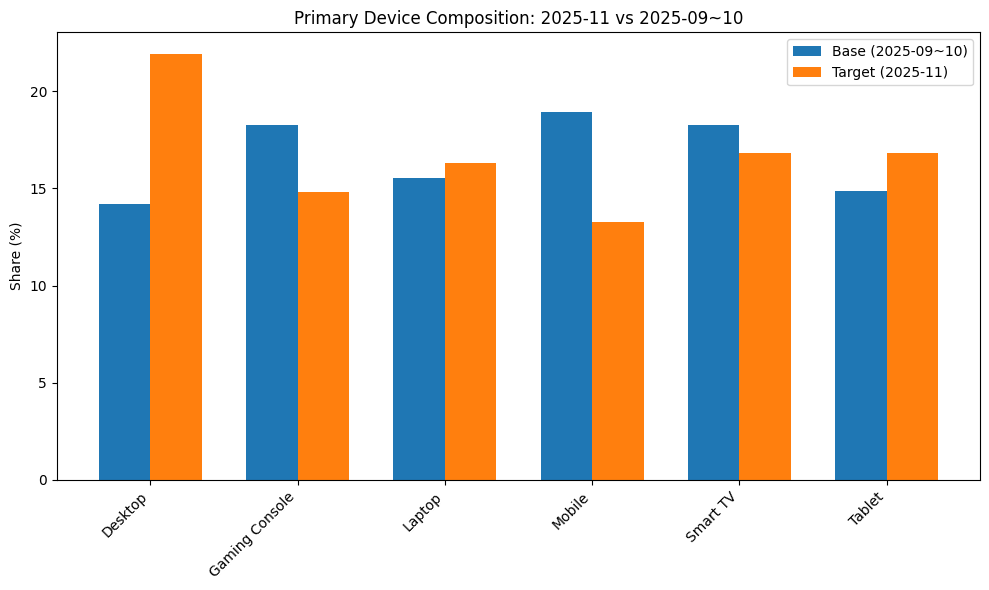

compare_group,Base (2025-09~10),Target (2025-11)
primary_device,,
Desktop,0.141892,0.219388
Gaming Console,0.182432,0.147959
Laptop,0.155405,0.163265
Mobile,0.189189,0.132653
Smart TV,0.182432,0.168367
Tablet,0.148649,0.168367


In [14]:
# -------------------------------------------------
# [목적]
# compare_group 별로 primary_device 구성비를 비교
#
# [해석]
# 예를 들어 Target에서 Desktop 비중이 높아졌다면,
# 11월 churn 증가는 Desktop 사용자 비중 증가와 연결될 수 있음
# -------------------------------------------------

# 1) compare_group + primary_device 조합별 유저 수 집계
device_plot = (
    comparison_df
    .groupby(['compare_group', 'primary_device'])['user_id']
    .count()
    .reset_index(name='user_count')
)

# 2) 각 그룹 내 비율 계산
device_plot['share'] = (
    device_plot['user_count']
    / device_plot.groupby('compare_group')['user_count'].transform('sum')
)

# 3) 그래프용 pivot 변환
device_pivot = device_plot.pivot(
    index='primary_device',
    columns='compare_group',
    values='share'
).fillna(0)

# 4) 컬럼 순서 고정
device_pivot = device_pivot[['Base (2025-09~10)', 'Target (2025-11)']]

# 5) 막대 위치 계산
x = np.arange(len(device_pivot))
width = 0.35

# 6) 그래프 생성
plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    device_pivot['Base (2025-09~10)'] * 100,
    width=width,
    label='Base (2025-09~10)'
)

plt.bar(
    x + width/2,
    device_pivot['Target (2025-11)'] * 100,
    width=width,
    label='Target (2025-11)'
)

# 7) 축/제목 설정
plt.xticks(x, device_pivot.index.astype(str), rotation=45, ha='right')
plt.ylabel('Share (%)')
plt.title('Primary Device Composition: 2025-11 vs 2025-09~10')
plt.legend()
plt.tight_layout()
plt.show()

# 8) 표 확인
device_pivot

# 위 그래프 뽑은 이유 : 
- base 기간과 target 기간 별 primary_device 구성비를 비교

# 위 그래프의 해석 : 
- Target(11월)에서 Desktop 비중이 높아짐 -> 11월 churn 증가는 Desktop 사용자 비중 증가와 연결될 수 있음




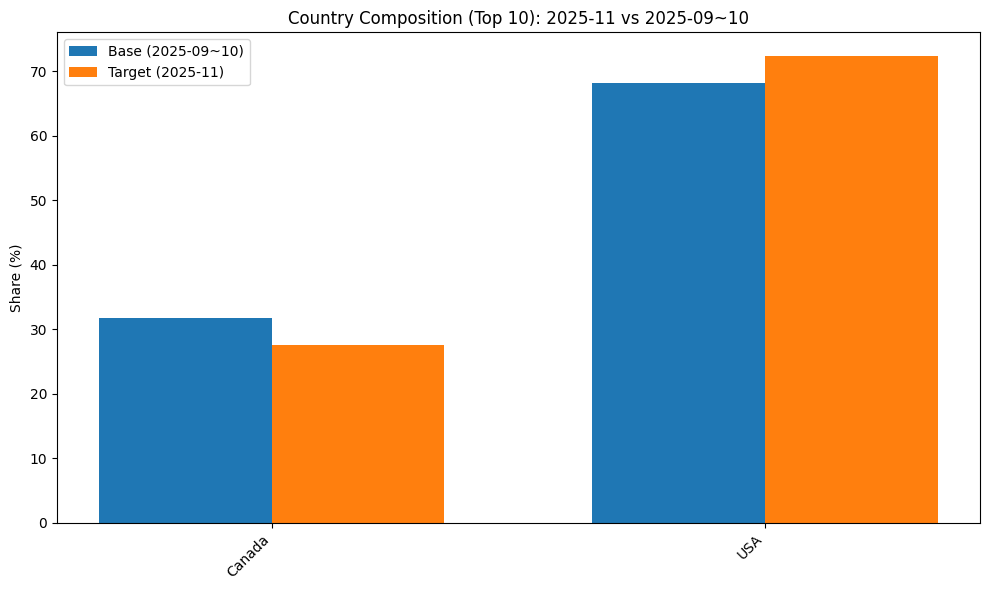

compare_group,Base (2025-09~10),Target (2025-11)
country,,
Canada,0.317568,0.27551
USA,0.682432,0.72449


In [15]:
# -------------------------------------------------
# [목적]
# compare_group 별로 country 구성비를 비교
#
# [주의]
# 국가는 종류가 많아서 전부 그리면 너무 복잡해질 수 있음
# 그래서 전체 유저 수 기준 상위 10개 국가만 표시
# -------------------------------------------------

# 1) compare_group + country 조합별 유저 수 집계
country_plot = (
    comparison_df
    .groupby(['compare_group', 'country'])['user_id']
    .count()
    .reset_index(name='user_count')
)

# 2) 전체 기준 상위 10개 국가 찾기
#    Base와 Target을 합쳐서 총합이 큰 국가 10개만 남김
top_countries = (
    country_plot
    .groupby('country')['user_count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# 3) 상위 10개 국가만 남김
country_plot = country_plot[
    country_plot['country'].isin(top_countries)
].copy()

# 4) 각 그룹 내 비율 계산
country_plot['share'] = (
    country_plot['user_count']
    / country_plot.groupby('compare_group')['user_count'].transform('sum')
)

# 5) 그래프용 pivot
country_pivot = country_plot.pivot(
    index='country',
    columns='compare_group',
    values='share'
).fillna(0)

# 6) 컬럼 순서 고정
country_pivot = country_pivot[['Base (2025-09~10)', 'Target (2025-11)']]

# 7) 막대 위치 계산
x = np.arange(len(country_pivot))
width = 0.35

# 8) 그래프 생성
plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    country_pivot['Base (2025-09~10)'] * 100,
    width=width,
    label='Base (2025-09~10)'
)

plt.bar(
    x + width/2,
    country_pivot['Target (2025-11)'] * 100,
    width=width,
    label='Target (2025-11)'
)

# 9) 축/제목 설정
plt.xticks(x, country_pivot.index.astype(str), rotation=45, ha='right')
plt.ylabel('Share (%)')
plt.title('Country Composition (Top 10): 2025-11 vs 2025-09~10')
plt.legend()
plt.tight_layout()
plt.show()

# 10) 표 확인
country_pivot

# 위 그래프 뽑은 이유 : 
- base 기간과 target 기간 별 country 구성비를 비교

# 위 그래프의 해석 : 
- USA가 데이터도 많고 이탈율도 높음음


C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\3476953450.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['compare_group', 'age_group'])['user_id']


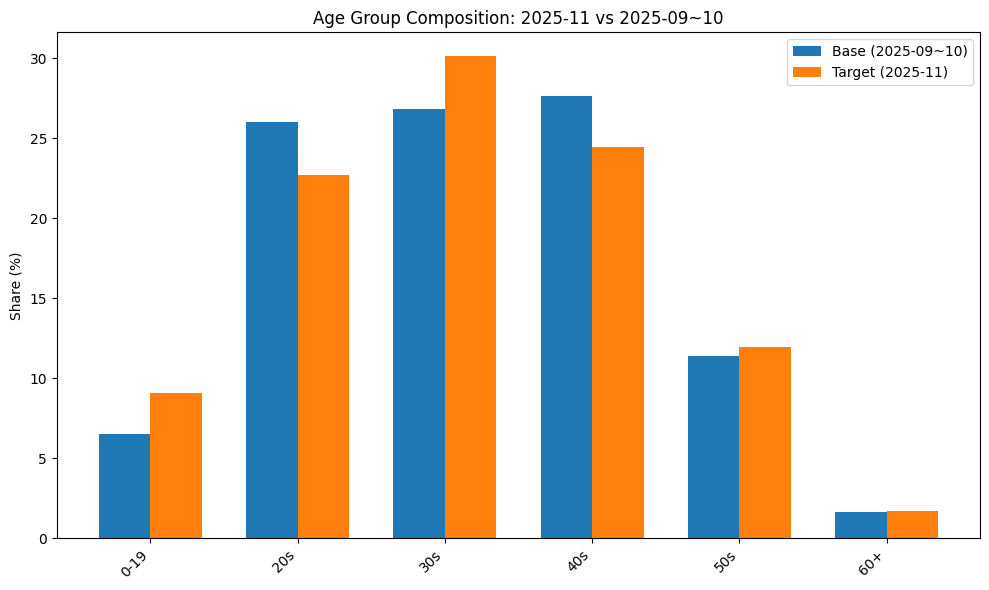

compare_group,Base (2025-09~10),Target (2025-11)
age_group,,
0-19,0.065041,0.090909
20s,0.260163,0.227273
30s,0.268293,0.301136
40s,0.276423,0.244318
50s,0.113821,0.119318
60+,0.016260,0.017045


In [16]:
# -------------------------------------------------
# [목적]
# compare_group 별로 age_group 구성비를 비교
#
# [주의]
# age는 숫자형이므로 바로 그래프에 쓰기보다
# 연령대 구간(age_group)으로 묶어서 비교하는 것이 더 해석하기 좋음
# -------------------------------------------------

# 1) comparison_df를 복사해서 연령대용 임시 df 생성
age_plot_df = comparison_df.copy()

# 2) age를 연령대 구간으로 변환
#    0~19 / 20s / 30s / 40s / 50s / 60+
age_plot_df['age_group'] = pd.cut(
    age_plot_df['age'],
    bins=[0, 19, 29, 39, 49, 59, 200],
    labels=['0-19', '20s', '30s', '40s', '50s', '60+'],
    right=True
)

# 3) compare_group + age_group 조합별 유저 수 집계
age_plot = (
    age_plot_df
    .groupby(['compare_group', 'age_group'])['user_id']
    .count()
    .reset_index(name='user_count')
)

# 4) 그룹 내 비율 계산
age_plot['share'] = (
    age_plot['user_count']
    / age_plot.groupby('compare_group')['user_count'].transform('sum')
)

# 5) 그래프용 pivot
age_pivot = age_plot.pivot(
    index='age_group',
    columns='compare_group',
    values='share'
).fillna(0)

# 6) 컬럼 순서 고정
age_pivot = age_pivot[['Base (2025-09~10)', 'Target (2025-11)']]

# 7) 막대 위치 계산
x = np.arange(len(age_pivot))
width = 0.35

# 8) 그래프 생성
plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    age_pivot['Base (2025-09~10)'] * 100,
    width=width,
    label='Base (2025-09~10)'
)

plt.bar(
    x + width/2,
    age_pivot['Target (2025-11)'] * 100,
    width=width,
    label='Target (2025-11)'
)

# 9) 축/제목 설정
plt.xticks(x, age_pivot.index.astype(str), rotation=45, ha='right')
plt.ylabel('Share (%)')
plt.title('Age Group Composition: 2025-11 vs 2025-09~10')
plt.legend()
plt.tight_layout()
plt.show()

# 10) 표 확인
age_pivot

# 위 그래프 뽑은 이유 : 
- base 기간과 target 기간 별 age_group 구성비를 비교

# 위 그래프의 해석 : 
- AGE 별로 큰 연관성은 없음.

In [17]:
# from something import NetflixFeatureBuilder

# builder = NetflixFeatureBuilder(
#     user=user,
#     watch=watch,
#     reviews=reviews,
#     rec_logs=rec_logs,
#     search_logs=search_logs,
#     movies=movies
# )

# print(hasattr(builder, 'new_user'))  # True 나와야 정상

In [18]:
builder.add_recommendation_click_rate()
builder.add_content_interactions()
builder.add_rating_given()
builder.add_completion_rate()
builder.add_watch_sessions_per_week()
builder.add_avg_watch_time_minutes()
builder.add_favorite_genre()


new_user = builder.get_data()
new_user.head()

c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({
c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({


,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,estimated_churn_date_p50,is_p50_estimate_valid,final_estimated_churn_date,recommendation_click_rate,content_interactions,rating_given,completion_rate,watch_sessions_per_week,avg_watch_time_minutes,favorite_genre
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,2025-12-07,True,NaT,0,2,4,50,1,44,War
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,2026-01-15,True,NaT,0,4,4,33,1,51,Horror
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,2025-08-01,True,2025-08-01,33,3,4,37,1,74,Animation
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,2026-02-05,True,NaT,0,3,3,28,1,82,Family
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,2025-11-06,True,NaT,0,4,3,22,1,40,Biography


C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\2752829613.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


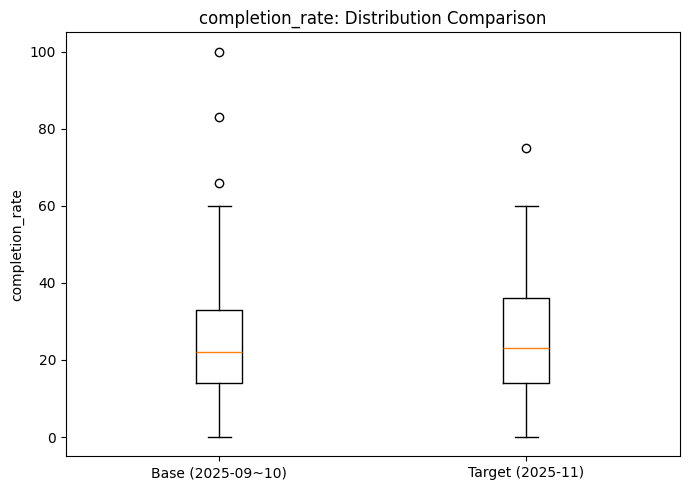

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\2752829613.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


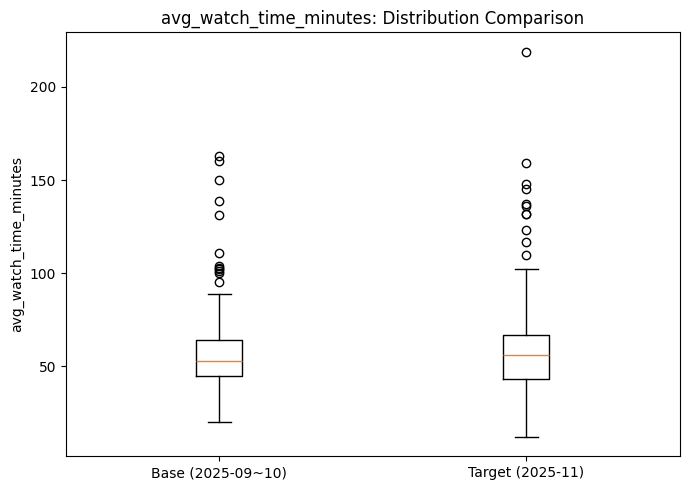

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\2752829613.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


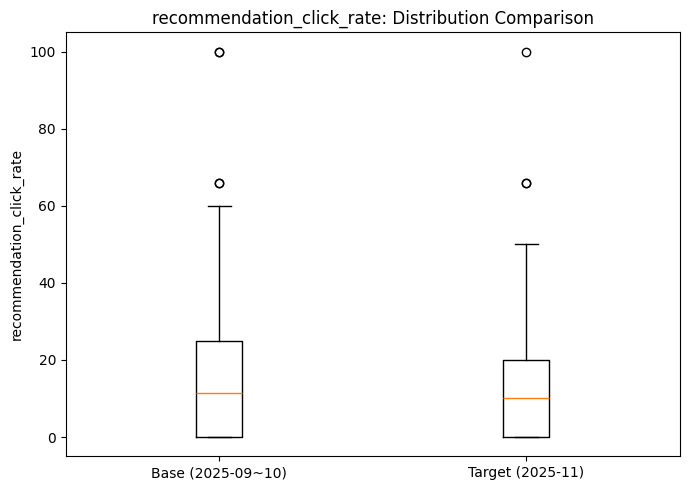

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\2752829613.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


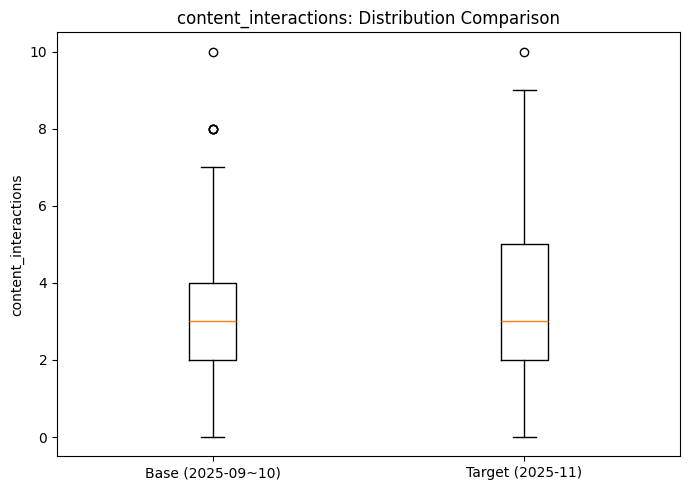

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\2752829613.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


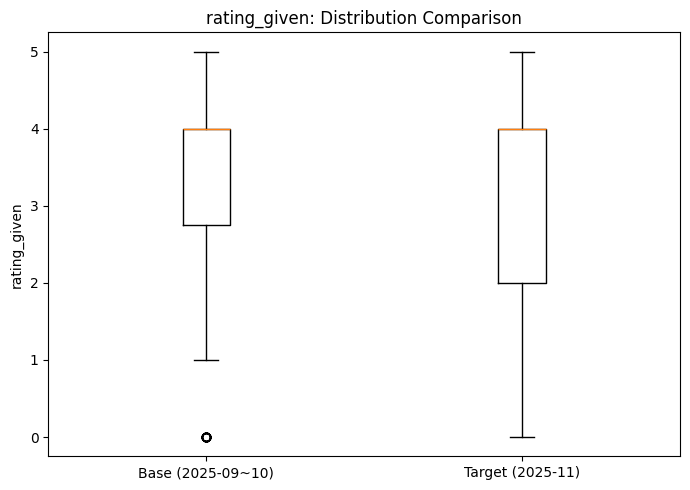

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# [목적]
# 2025-11 estimated churn 유저(Target)와
# 2025-09~10 estimated churn 유저(Base)를 비교해서
# 각 행동 지표의 "분포"를 boxplot으로 확인한다.
#
# [왜 이걸 보나?]
# 평균만 보면 일부 큰 값/작은 값 때문에 왜곡될 수 있다.
# boxplot은 중앙값, 퍼짐, 이상치를 같이 보여줘서
# "11월 churn 유저의 행동이 실제로 전체적으로 나빠졌는지"
# 더 잘 확인할 수 있다.
#
# [주의]
# - new_user 자체는 수정하지 않음
# - 그래프용 임시 df만 사용
# -------------------------------------------------

# 1) 비교에 필요한 컬럼만 복사
behavior_plot_df = new_user[
    [
        'user_id',
        'is_active',
        'final_estimated_churn_date',
        'completion_rate',
        'avg_watch_time_minutes',
        'recommendation_click_rate',
        'content_interactions',
        'rating_given'
    ]
].copy()

# 2) 날짜형으로 변환
behavior_plot_df['final_estimated_churn_date'] = pd.to_datetime(
    behavior_plot_df['final_estimated_churn_date'],
    errors='coerce'
)

# 3) churn 유저만 남기기
behavior_plot_df = behavior_plot_df[
    (behavior_plot_df['is_active'] == False) &
    (behavior_plot_df['final_estimated_churn_date'].notna())
].copy()

# 4) month를 임시로 계산
estimated_month = (
    behavior_plot_df['final_estimated_churn_date']
    .dt.to_period('M')
    .astype(str)
)

# 5) 비교 그룹 만들기
#    - 2025-11 -> Target
#    - 2025-09~10 -> Base
behavior_plot_df['compare_group'] = None

behavior_plot_df.loc[
    estimated_month == '2025-11',
    'compare_group'
] = 'Target (2025-11)'

behavior_plot_df.loc[
    estimated_month.isin(['2025-09', '2025-10']),
    'compare_group'
] = 'Base (2025-09~10)'

# 6) Base / Target만 남기기
behavior_plot_df = behavior_plot_df[
    behavior_plot_df['compare_group'].notna()
].copy()

# 7) 비교할 행동 컬럼 목록
behavior_columns = [
    'completion_rate',
    'avg_watch_time_minutes',
    'recommendation_click_rate',
    'content_interactions',
    'rating_given'
]

# 8) 컬럼별로 boxplot 생성
for col in behavior_columns:
    # boxplot용 데이터 준비
    base_values = behavior_plot_df.loc[
        behavior_plot_df['compare_group'] == 'Base (2025-09~10)', col
    ].dropna()

    target_values = behavior_plot_df.loc[
        behavior_plot_df['compare_group'] == 'Target (2025-11)', col
    ].dropna()

    # 그래프
    plt.figure(figsize=(7, 5))
    plt.boxplot(
        [base_values, target_values],
        labels=['Base (2025-09~10)', 'Target (2025-11)']
    )

    plt.ylabel(col)
    plt.title(f'{col}: Distribution Comparison')
    plt.tight_layout()
    plt.show()

# [목적]
### 2025-11 estimated churn 유저(Target)와
### 2025-09~10 estimated churn 유저(Base)를 비교해서
### 각 행동 지표의 "분포"를 boxplot으로 확인한다.

# [왜 이걸 보나?]
### 평균만 보면 일부 큰 값/작은 값 때문에 왜곡될 수 있다.
### boxplot은 중앙값, 퍼짐, 이상치를 같이 보여줘서
### "11월 churn 유저의 행동이 실제로 전체적으로 나빠졌는지"
### 더 잘 확인할 수 있다.

# 1. completion_rate
보이는 점
11월(Target) 상자가 Base보다 아래로 내려가 있지 않음
중앙값도 오히려 비슷하거나 약간 더 높아 보임
전체 분포도 크게 나빠진 느낌은 아님
해석

11월 churn 유저가 9~10월 churn 유저보다 끝까지 덜 본다고 보긴 어렵다.
즉 완료율 저하가 11월 churn 증가를 설명하는 핵심 요인으로 보이진 않는다.

# 2. avg_watch_time_minutes
보이는 점
11월(Target) 상자가 전체적으로 약간 위쪽
중앙값도 11월이 조금 더 높아 보임
상단 이상치도 11월 쪽이 더 큼
해석

11월 churn 유저는 오히려 시청시간이 줄었다기보다 유지되거나 조금 더 높은 패턴을 보인다.
따라서 11월 churn 증가는 단순히 덜 보는 사용자 증가로 해석하기 어렵다.

더 자연스러운 말

11월 churn 유저는 아예 사용량이 줄어든다기보다, 한 번 볼 때는 계속 보는 사용자가 포함되어 있을 가능성이 있다.

# 3. recommendation_click_rate
보이는 점
11월(Target) 상자가 조금 더 아래쪽
중앙값도 살짝 낮아 보임
상단 범위도 Base보다 약간 낮음
해석

11월 churn 유저는 9~10월 대비 추천에 덜 반응하는 경향이 있는 것으로 보인다.
이 5개 지표 중에서는 가장 직접적으로 “나빠진 신호”에 가까운 그래프다.

발표용 문장

11월 churn 유저는 추천 클릭률 분포가 소폭 낮아져, 추천 기반 탐색 반응성이 약화된 패턴을 보였다.

# 4. content_interactions
보이는 점
중앙값은 거의 비슷함
11월(Target)은 상자 윗부분과 whisker가 오히려 조금 더 큼
즉 낮아졌다기보다 비슷하거나 일부는 더 활발
해석

11월 churn 유저의 상호작용 수가 전반적으로 더 낮아졌다고 보긴 어렵다.
따라서 참여도 저하를 강하게 주장하기엔 이 그래프만으로는 부족하다.

안전한 표현

콘텐츠 상호작용 수는 9~10월과 큰 차이를 보이지 않았고, 일부 구간에서는 오히려 더 높은 값도 관찰되었다.

# 5. rating_given
보이는 점
중앙값은 거의 비슷해 보임
다만 11월(Target)은 하단이 조금 더 아래로 내려감
즉 일부 낮은 평점 유저가 더 포함된 느낌은 있음
해석

11월 churn 유저의 콘텐츠 만족도가 전반적으로 크게 나빠졌다고 보긴 어렵지만,
낮은 평점을 준 일부 사용자군이 더 포함되었을 가능성은 있다.

안전한 발표 문장

평점 분포의 중심은 유사했으나, 11월 churn 유저에서 낮은 평점 구간이 일부 더 확대되어 만족도 저하 신호가 부분적으로 관찰되었다.

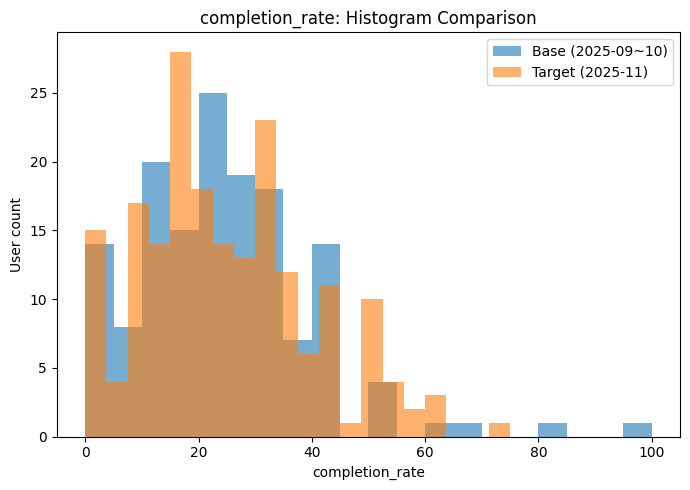

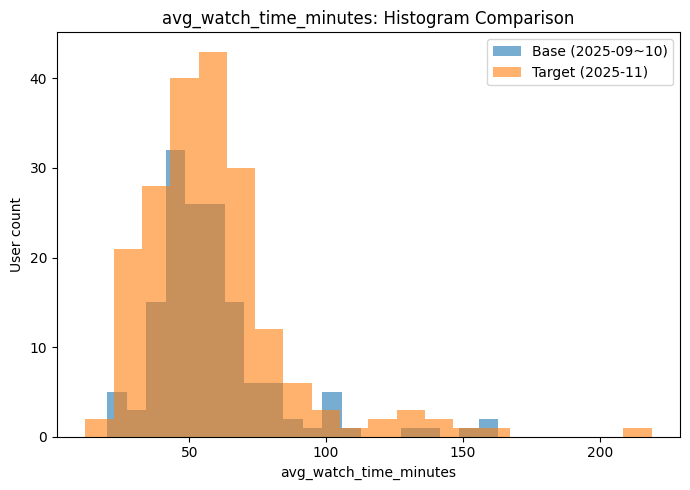

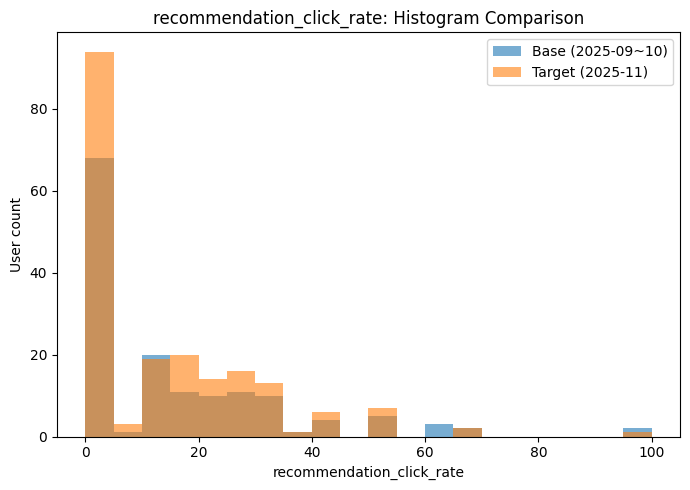

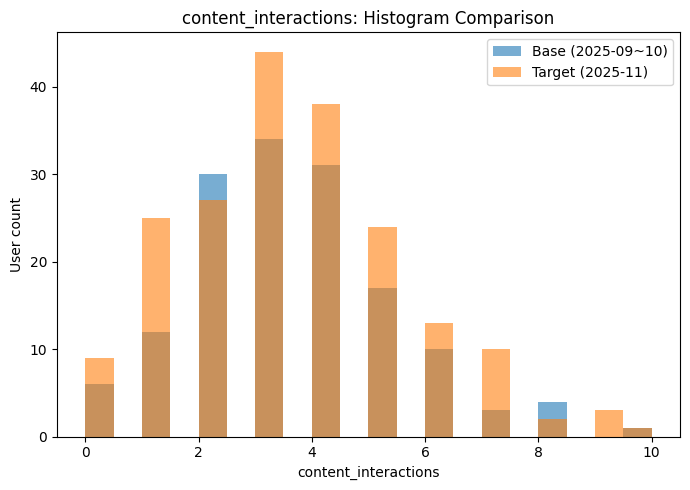

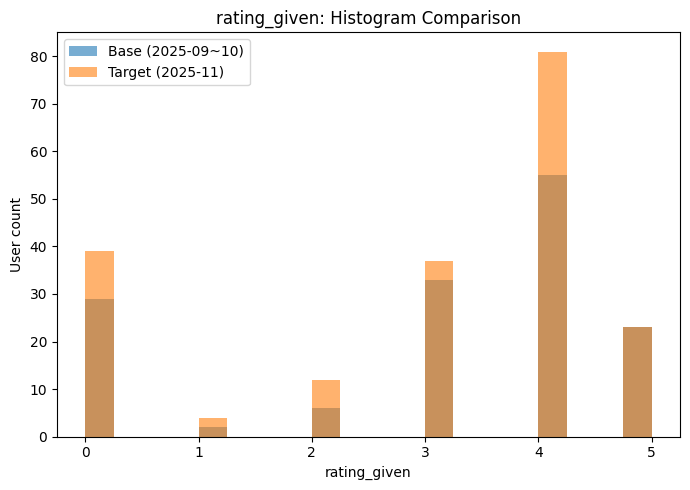

In [20]:
import matplotlib.pyplot as plt

# -------------------------------------------------
# [목적]
# 각 행동 지표에 대해
# Base vs Target 분포를 히스토그램으로 비교
# -------------------------------------------------

for col in behavior_columns:
    base_values = behavior_plot_df.loc[
        behavior_plot_df['compare_group'] == 'Base (2025-09~10)', col
    ].dropna()

    target_values = behavior_plot_df.loc[
        behavior_plot_df['compare_group'] == 'Target (2025-11)', col
    ].dropna()

    plt.figure(figsize=(7, 5))
    plt.hist(base_values, bins=20, alpha=0.6, label='Base (2025-09~10)')
    plt.hist(target_values, bins=20, alpha=0.6, label='Target (2025-11)')

    plt.xlabel(col)
    plt.ylabel('User count')
    plt.title(f'{col}: Histogram Comparison')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [21]:
builder.add_review_helpfulness_ratio()
builder.add_binge_day_ratio()
builder.add_avg_search_duration_seconds()

new_user = builder.get_data()
new_user.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,recommendation_click_rate,content_interactions,rating_given,completion_rate,watch_sessions_per_week,avg_watch_time_minutes,favorite_genre,review_helpfulness_ratio,binge_day_ratio,avg_search_duration_seconds
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,0,2,4,50,1,44,War,0.000000,0.0,27.50
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,0,4,4,33,1,51,Horror,0.805556,0.0,18.10
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,33,3,4,37,1,74,Animation,0.000000,0.0,0.00
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,0,3,3,28,1,82,Family,1.000000,0.0,26.55
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,0,4,3,22,1,40,Biography,0.875000,0.0,37.70


C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\3602568837.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


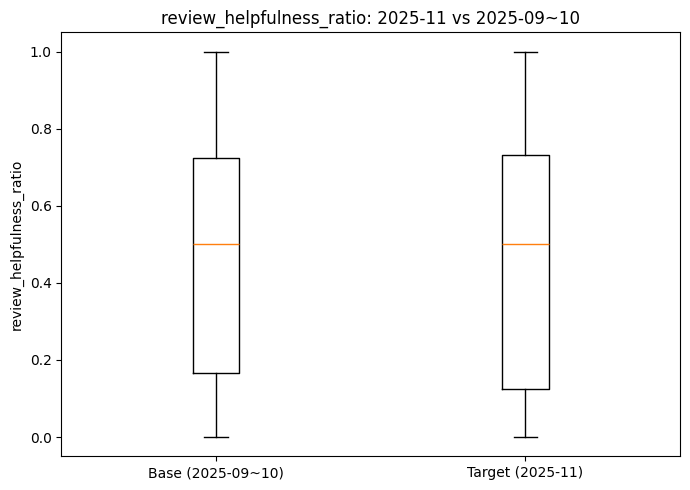

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\3602568837.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


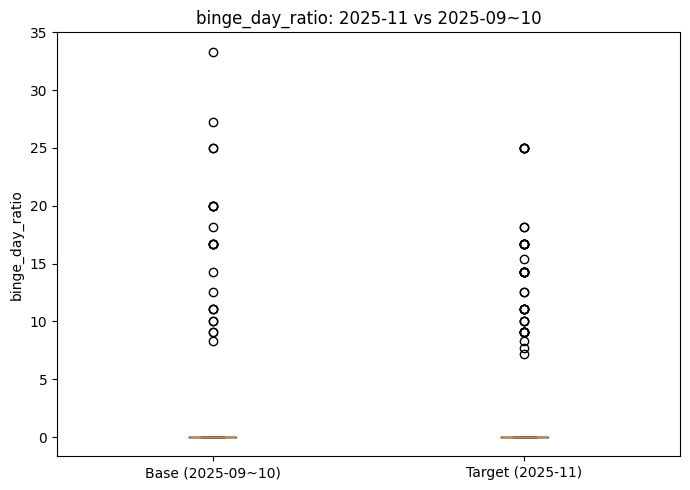

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\3602568837.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


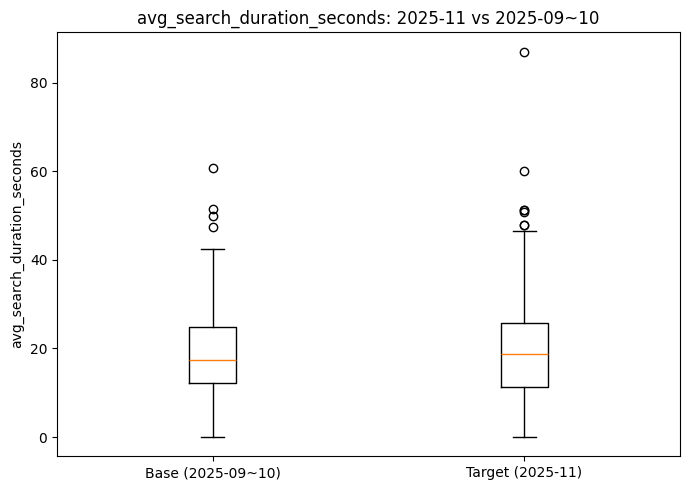

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# [목적]
# 새로 추가한 3개 컬럼에 대해
# 2025-09~10 estimated churn 유저(Base)와
# 2025-11 estimated churn 유저(Target)의 분포를 boxplot으로 비교
#
# [비교 컬럼]
# 1. review_helpfulness_ratio
# 2. binge_day_ratio
# 3. avg_search_duration_seconds
#
# [주의]
# - new_user 자체는 수정하지 않음
# - 그래프용 임시 데이터프레임만 사용
# -------------------------------------------------

# 1) 비교에 필요한 컬럼만 new_user에서 복사
boxplot_df = new_user[
    [
        'user_id',
        'is_active',
        'final_estimated_churn_date',
        'review_helpfulness_ratio',
        'binge_day_ratio',
        'avg_search_duration_seconds'
    ]
].copy()

# 2) final_estimated_churn_date를 날짜형으로 변환
#    문자열 상태일 수 있으므로 month 추출을 위해 datetime으로 변환
boxplot_df['final_estimated_churn_date'] = pd.to_datetime(
    boxplot_df['final_estimated_churn_date'],
    errors='coerce'
)

# 3) churn 유저만 남기기
#    이번 비교는 "estimated churn 유저"끼리의 비교이므로
#    is_active == False 이고 날짜가 있는 유저만 사용
boxplot_df = boxplot_df[
    (boxplot_df['is_active'] == False) &
    (boxplot_df['final_estimated_churn_date'].notna())
].copy()

# 4) final_estimated_churn_date에서 월 문자열을 임시 생성
#    예: '2025-11'
#    new_user에는 저장하지 않고 여기서만 사용
estimated_month = (
    boxplot_df['final_estimated_churn_date']
    .dt.to_period('M')
    .astype(str)
)

# 5) 비교 그룹 만들기
#    - 2025-11 -> Target
#    - 2025-09, 2025-10 -> Base
boxplot_df['compare_group'] = None

boxplot_df.loc[
    estimated_month == '2025-11',
    'compare_group'
] = 'Target (2025-11)'

boxplot_df.loc[
    estimated_month.isin(['2025-09', '2025-10']),
    'compare_group'
] = 'Base (2025-09~10)'

# 6) Base / Target으로 분류된 유저만 남기기
boxplot_df = boxplot_df[
    boxplot_df['compare_group'].notna()
].copy()

# 7) 비교할 컬럼 목록
comparison_columns = [
    'review_helpfulness_ratio',
    'binge_day_ratio',
    'avg_search_duration_seconds'
]

# 8) 컬럼 하나씩 boxplot 그리기
for col in comparison_columns:

    # Base 그룹 값 추출
    base_values = boxplot_df.loc[
        boxplot_df['compare_group'] == 'Base (2025-09~10)',
        col
    ].dropna()

    # Target 그룹 값 추출
    target_values = boxplot_df.loc[
        boxplot_df['compare_group'] == 'Target (2025-11)',
        col
    ].dropna()

    # 그래프 생성
    plt.figure(figsize=(7, 5))
    plt.boxplot(
        [base_values, target_values],
        labels=['Base (2025-09~10)', 'Target (2025-11)']
    )

    # 축/제목 설정
    plt.ylabel(col)
    plt.title(f'{col}: 2025-11 vs 2025-09~10')
    plt.tight_layout()
    plt.show()

# [목적]
### 새로 추가한 3개 컬럼에 대해
### 2025-09~10 estimated churn 유저(Base)와
### 2025-11 estimated churn 유저(Target)의 분포를 boxplot으로 비교

# [비교 컬럼]
### 1. review_helpfulness_ratio
### 2. binge_day_ratio
### 3. avg_search_duration_seconds

# 1. avg_search_duration_seconds
보이는 점
11월(Target) 박스가 Base보다 약간 위
중앙값도 11월이 조금 더 높아 보임
상단 이상치도 11월 쪽이 더 큼
해석

11월 churn 유저는 9~10월 churn 유저보다 검색에 조금 더 오래 머무는 경향이 있는 것으로 보인다.
이는 원하는 콘텐츠를 찾는 과정에서 탐색 마찰이 약간 커졌을 가능성을 시사한다.

다만 주의
차이가 아주 크진 않아서
강한 원인이라기보다는
보조적인 신호 정도로 보는 게 맞아.
발표용 문장

avg_search_duration_seconds는 11월 churn 유저에서 소폭 높게 나타나, 콘텐츠 탐색 과정의 마찰 가능성을 일부 시사했다. 다만 분포 차이가 크지 않아 핵심 단일 요인으로 보기는 어렵다.

# 2. binge_day_ratio
보이는 점
Base, Target 둘 다 박스 자체가 거의 0에 붙어 있음
즉 대부분 유저는 binge_day_ratio = 0 근처
일부 outlier만 존재하는데, Base 쪽이 오히려 더 큰 극단값도 보임
해석

대부분의 churn 유저는 Base와 Target 모두에서 몰아보기 비율이 거의 없는 수준으로 나타났다.
즉 binge_day_ratio는 전체적인 집단 차이를 설명하는 지표로 보기 어렵다.

더 쉽게 말하면
몰아보기 성향이 있는 유저가 아예 없는 건 아니지만
그건 일부 유저 얘기
11월 전체 churn 증가를 설명하는 핵심 패턴은 아님
발표용 문장

binge_day_ratio는 Base와 Target 모두 대부분 0에 가까워, 11월 churn 증가가 전반적인 몰아보기 성향 변화와 함께 나타났다고 보긴 어려웠다. 일부 극단값은 존재했지만 전체 집단 차이라기보다 일부 사용자군의 영향으로 해석하는 것이 적절하다.

# 3. review_helpfulness_ratio
보이는 점
Base와 Target의 박스 모양이 거의 동일
중앙값도 거의 같고
전체 퍼짐도 큰 차이가 없어 보임
해석

11월 churn 유저와 9~10월 churn 유저의 review_helpfulness_ratio 분포는 거의 유사하다.
따라서 리뷰가 얼마나 유용하게 받아들여졌는지는 11월 churn 증가를 설명하는 핵심 변수로 보기 어렵다.

발표용 문장

review_helpfulness_ratio는 Base와 Target 간 분포 차이가 거의 없어, 리뷰 반응의 질 자체는 11월 churn 증가를 직접적으로 설명하는 핵심 요인으로 보기 어려웠다.

In [23]:
# -------------------------------------------------
# 2025-11 estimated churn 유저 중
# 상위 요금제 vs 하위 요금제 비교용 데이터 만들기
# -------------------------------------------------

# 1. 필요한 컬럼만 new_user에서 복사
tier_df = new_user[
    [
        'user_id',
        'is_active',
        'final_estimated_churn_date',
        'subscription_plan',
        'recommendation_click_rate',
        'rating_given',
        'content_interactions'
    ]
].copy()

# 2. final_estimated_churn_date를 날짜형으로 변환
tier_df['final_estimated_churn_date'] = pd.to_datetime(
    tier_df['final_estimated_churn_date'],
    errors='coerce'
)

# 3. final_estimated_churn_date에서 월 문자열을 임시로 생성
#    예: 2025-11
estimated_month = (
    tier_df['final_estimated_churn_date']
    .dt.to_period('M')
    .astype(str)
)

# 4. 2025-11 estimated churn 유저만 사용
tier_df = tier_df[
    (tier_df['is_active'] == False) &
    (estimated_month == '2025-11')
].copy()

# 5. 상위/하위 요금제 그룹 만들기
#    - High tier: Premium, Premium+
#    - Low tier: Basic, Standard
tier_df['tier_group'] = None

tier_df.loc[
    tier_df['subscription_plan'].isin(['Premium', 'Premium+']),
    'tier_group'
] = 'High tier'

tier_df.loc[
    tier_df['subscription_plan'].isin(['Basic', 'Standard']),
    'tier_group'
] = 'Low tier'

# 6. 필요한 행만 남기기
tier_df = tier_df[tier_df['tier_group'].notna()].copy()

# 7. 확인
tier_df[['user_id', 'subscription_plan', 'tier_group']].head()

,user_id,subscription_plan,tier_group
115,user_00116,Standard,Low tier
145,user_00146,Premium+,High tier
182,user_00183,Premium,High tier
231,user_00232,Premium,High tier
273,user_00274,Standard,Low tier


C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\70053815.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


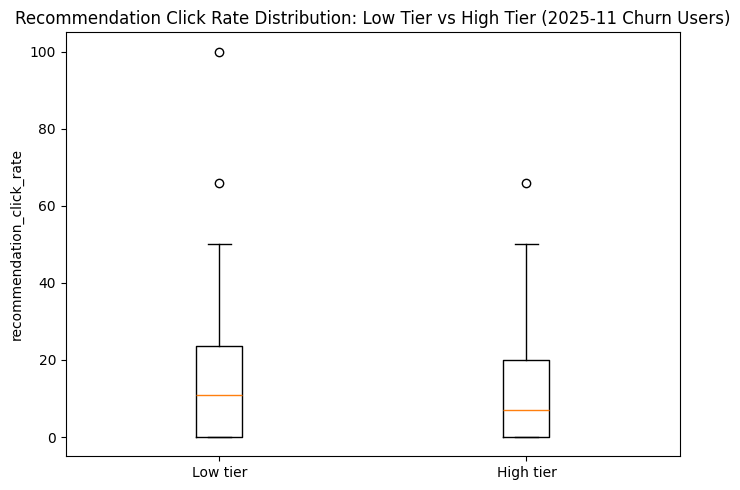

In [24]:
# -------------------------------------------------
# recommendation_click_rate 분포 비교
# High tier vs Low tier
# -------------------------------------------------

low_values = tier_df.loc[
    tier_df['tier_group'] == 'Low tier',
    'recommendation_click_rate'
].dropna()

high_values = tier_df.loc[
    tier_df['tier_group'] == 'High tier',
    'recommendation_click_rate'
].dropna()

plt.figure(figsize=(7, 5))
plt.boxplot(
    [low_values, high_values],
    labels=['Low tier', 'High tier']
)

plt.ylabel('recommendation_click_rate')
plt.title('Recommendation Click Rate Distribution: Low Tier vs High Tier (2025-11 Churn Users)')
plt.tight_layout()
plt.show()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\2840452591.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


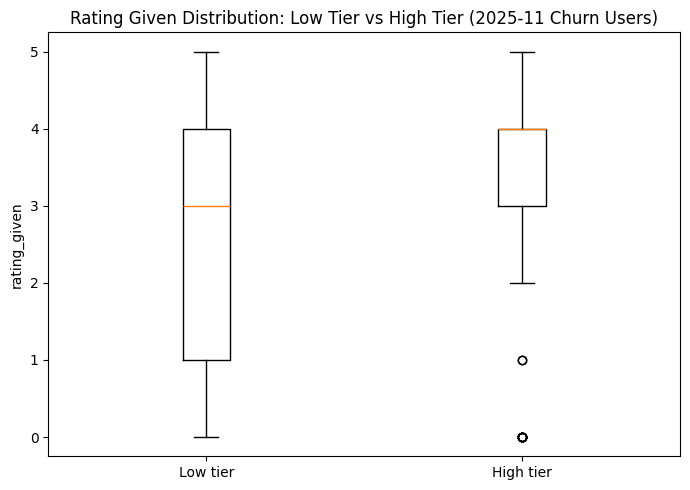

In [25]:
# -------------------------------------------------
# rating_given 분포 비교
# High tier vs Low tier
# -------------------------------------------------

low_values = tier_df.loc[
    tier_df['tier_group'] == 'Low tier',
    'rating_given'
].dropna()

high_values = tier_df.loc[
    tier_df['tier_group'] == 'High tier',
    'rating_given'
].dropna()

plt.figure(figsize=(7, 5))
plt.boxplot(
    [low_values, high_values],
    labels=['Low tier', 'High tier']
)

plt.ylabel('rating_given')
plt.title('Rating Given Distribution: Low Tier vs High Tier (2025-11 Churn Users)')
plt.tight_layout()
plt.show()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\3316513555.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


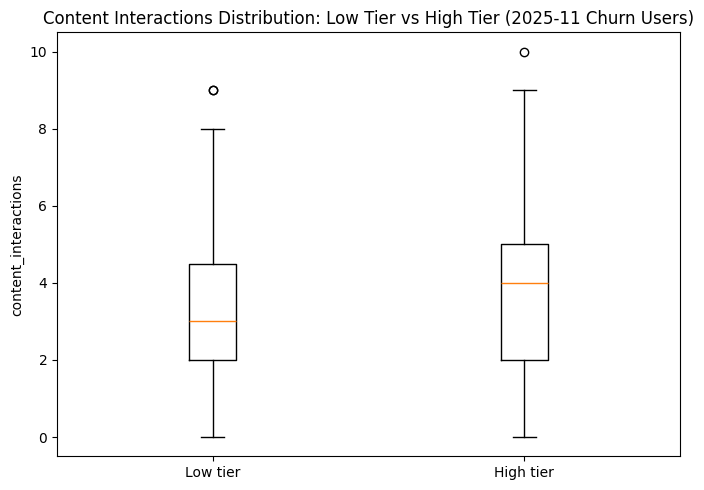

In [26]:
# -------------------------------------------------
# content_interactions 분포 비교
# High tier vs Low tier
# -------------------------------------------------

low_values = tier_df.loc[
    tier_df['tier_group'] == 'Low tier',
    'content_interactions'
].dropna()

high_values = tier_df.loc[
    tier_df['tier_group'] == 'High tier',
    'content_interactions'
].dropna()

plt.figure(figsize=(7, 5))
plt.boxplot(
    [low_values, high_values],
    labels=['Low tier', 'High tier']
)

plt.ylabel('content_interactions')
plt.title('Content Interactions Distribution: Low Tier vs High Tier (2025-11 Churn Users)')
plt.tight_layout()
plt.show()

# 1. recommendation_click_rate
보이는 점
High tier 상자가 Low tier보다 아래
중앙값도 High tier가 더 낮아 보임
전체적으로 High tier가 추천 클릭률이 더 낮은 쪽에 분포
해석

11월 churn 유저 중에서는 상위 요금제 유저가 하위 요금제 유저보다 추천에 덜 반응하는 경향이 나타난다.

즉:

Premium / Premium+ 유저는
Basic / Standard 유저보다
추천 피드에 대한 반응성이 더 약한 상태에서 churn한 것으로 볼 수 있어.
발표용 문장

2025년 11월 estimated churn 유저를 요금제 기준으로 나누어 비교한 결과, High tier 유저는 Low tier 유저보다 recommendation_click_rate 분포가 더 낮게 나타났다. 이는 상위 요금제 churn 유저에서 추천 기반 탐색 반응성이 더 약해졌음을 시사한다.

# 2.rating_given
보이는 점
High tier 상자가 Low tier보다 전체적으로 위쪽
중앙값도 High tier가 더 높아 보임
Low tier는 하단 범위가 더 넓고, 낮은 평점 구간이 더 많이 포함됨
High tier도 낮은 값 outlier는 있지만, 전체 중심은 더 높은 쪽에 있음
해석

2025년 11월 churn 유저 중에서는 상위 요금제 유저가 하위 요금제 유저보다 콘텐츠를 더 좋게 평가하는 경향이 나타난다.

즉,

Premium / Premium+ churn 유저는
Basic / Standard churn 유저보다
콘텐츠 만족도 자체는 더 낮지 않다. 오히려 더 높은 편이야.

이게 중요한 이유는,
앞에서 본 recommendation_click_rate에서는 High tier가 더 낮았잖아.
그런데 rating_given은 더 높아.

그러면 해석이 이렇게 연결돼.

상위 요금제 churn 유저는 콘텐츠가 마음에 안 들어서 떠난다기보다,
콘텐츠 만족은 유지되지만 추천 반응성은 약해진 상태에서 churn한 패턴일 가능성이 높다.

발표용 문장

2025년 11월 estimated churn 유저를 요금제 기준으로 나누어 비교한 결과, High tier 유저는 Low tier 유저보다 rating_given 분포가 더 높게 나타났다. 이는 상위 요금제 churn 유저가 콘텐츠 자체에는 상대적으로 더 높은 만족도를 보였음을 의미하며, 이들의 churn은 콘텐츠 불만보다 추천 반응성 저하나 플랫폼 사용 방식 변화와 더 관련 있을 가능성을 시사한다.

# 3. content_interactions
보이는 점
High tier 상자가 Low tier보다 약간 위
중앙값도 High tier가 조금 더 높음
상단 범위도 High tier 쪽이 더 넓음
해석

11월 churn 유저 중에서는 상위 요금제 유저가 하위 요금제 유저보다 전체 상호작용 수는 오히려 더 높은 편이다.

즉:

High tier 유저는 추천 클릭률은 낮았지만
리뷰/클릭/탐색을 포함한 전체 상호작용은 더 적지 않았어
그래서 상위 요금제 churn은 단순히 “서비스를 덜 써서 떠난 것”이라기보다,
플랫폼 안에서 활동은 하지만 추천에는 덜 반응하는 패턴으로 볼 수 있어.
발표용 문장

High tier churn 유저는 Low tier churn 유저보다 content_interactions 분포가 소폭 높게 나타났다. 이는 상위 요금제 유저가 플랫폼 내 활동 자체는 유지하면서도, 추천 반응성은 약화된 상태에서 churn했을 가능성을 시사한다.

In [27]:
import pandas as pd
import numpy as np

# =================================================
# [분석 기준 날짜]
# =================================================
NOV_START = pd.Timestamp('2025-11-01')
NOV_END = pd.Timestamp('2025-11-30')
DEC_START = pd.Timestamp('2025-12-01')

# =================================================
# [1] 기본 분석용 테이블 만들기
# - new_user에서 user 단위 기본 정보만 가져옴
# - 아직 new_user 자체는 수정하지 않음
# =================================================
analysis_df = new_user[
    [
        'user_id',
        'is_active',
        'final_estimated_churn_date',
        'subscription_plan',
        'primary_device',
        'country',
        'age'
    ]
].copy()

# 날짜형 변환
analysis_df['final_estimated_churn_date'] = pd.to_datetime(
    analysis_df['final_estimated_churn_date'],
    errors='coerce'
)

# =================================================
# [2] 그룹 라벨 정의
#
# 1) Churned in Nov:
#    final_estimated_churn_date가 11월 안에 있음
#
# 2) Survived after Nov:
#    - final_estimated_churn_date가 12월 이후이거나
#    - 아직 active이고 final_estimated_churn_date가 비어 있음
#
# 3) 11월 전에 이미 이탈한 사람은 제외
# =================================================
analysis_df['nov_group'] = None

mask_churned_in_nov = analysis_df['final_estimated_churn_date'].between(NOV_START, NOV_END)

mask_survived_after_nov = (
    (analysis_df['final_estimated_churn_date'] >= DEC_START)
    |
    (
        (analysis_df['is_active'] == True) &
        (analysis_df['final_estimated_churn_date'].isna())
    )
)

analysis_df.loc[mask_churned_in_nov, 'nov_group'] = 'Churned in Nov'
analysis_df.loc[mask_survived_after_nov, 'nov_group'] = 'Survived after Nov'

# 이번 분석에서 쓸 두 그룹만 남김
analysis_df = analysis_df[analysis_df['nov_group'].notna()].copy()

# =================================================
# [3] 11월 로그만 따로 잘라내는 함수
# - 행동 지표는 반드시 11월 로그만 사용
# =================================================
def keep_only_november(df, date_col):
    temp = df.copy()
    temp[date_col] = pd.to_datetime(temp[date_col], errors='coerce')
    temp = temp[temp[date_col].between(NOV_START, NOV_END)].copy()
    return temp

# 11월 로그만 추출
watch_nov = keep_only_november(watch, 'watch_date')
search_nov = keep_only_november(search_logs, 'search_date')
reviews_nov = keep_only_november(reviews, 'review_date')
rec_nov = keep_only_november(rec_logs, 'recommendation_date')  # recommendation_date 컬럼명 기준

# =================================================
# [4] recommendation_click_rate
# 정의:
# 11월 recommendation 로그 기준 user별 클릭 비율 * 100
# =================================================
rec_nov = rec_nov.copy()
rec_nov['was_clicked_num'] = rec_nov['was_clicked'].replace({
    True: 1, False: 0,
    'True': 1, 'False': 0,
    'true': 1, 'false': 0,
    1: 1, 0: 0
})
rec_nov['was_clicked_num'] = pd.to_numeric(rec_nov['was_clicked_num'], errors='coerce')

recommendation_click_rate_map = (
    rec_nov.groupby('user_id')['was_clicked_num']
    .mean()
    .mul(100)
    .to_dict()
)

# =================================================
# [5] rating_given
# 정의:
# 11월 리뷰 기준 user별 평균 평점
# =================================================
reviews_nov = reviews_nov.copy()
reviews_nov['rating'] = pd.to_numeric(reviews_nov['rating'], errors='coerce')

rating_given_map = (
    reviews_nov.groupby('user_id')['rating']
    .mean()
    .to_dict()
)

# =================================================
# [6] content_interactions
# 정의:
# 11월 기준
# = 리뷰 작성 수 + 추천 클릭 수 + 검색 결과 클릭 수
# =================================================
review_count = reviews_nov.groupby('user_id')['review_id'].count()

rec_click_count = rec_nov.groupby('user_id')['was_clicked_num'].sum()

search_click_tmp = search_nov[['user_id', 'clicked_result_position']].copy()
search_click_tmp['search_clicked'] = search_click_tmp['clicked_result_position'].notna().astype(int)
search_click_count = search_click_tmp.groupby('user_id')['search_clicked'].sum()

content_interactions_map = (
    review_count
    .add(rec_click_count, fill_value=0)
    .add(search_click_count, fill_value=0)
    .to_dict()
)

# =================================================
# [7] completion_rate
# 정의:
# 11월 watch 로그 기준
# completed 이거나 progress_percentage >= 100 이면 완료로 간주
# user별 완료 비율 * 100
# =================================================
watch_nov = watch_nov.copy()
watch_nov['progress_percentage'] = pd.to_numeric(watch_nov['progress_percentage'], errors='coerce')

watch_nov['is_completed'] = (
    (watch_nov['action'].astype(str).str.lower() == 'completed')
    |
    (watch_nov['progress_percentage'] >= 100)
).astype(int)

completion_rate_map = (
    watch_nov.groupby('user_id')['is_completed']
    .mean()
    .mul(100)
    .to_dict()
)

# =================================================
# [8] avg_watch_time_minutes
# 정의:
# 11월 기준 user별 하루 총 시청시간 평균
# =================================================
watch_nov['watch_date'] = pd.to_datetime(watch_nov['watch_date'], errors='coerce').dt.normalize()
watch_nov['watch_duration_minutes'] = pd.to_numeric(watch_nov['watch_duration_minutes'], errors='coerce')

daily_watch_minutes = (
    watch_nov.groupby(['user_id', 'watch_date'])['watch_duration_minutes']
    .sum()
    .reset_index(name='daily_watch_minutes')
)

avg_watch_time_minutes_map = (
    daily_watch_minutes.groupby('user_id')['daily_watch_minutes']
    .mean()
    .to_dict()
)

# =================================================
# [9] watch_sessions_per_week
# 정의:
# 11월 기준 user별 주간 session 수 평균
# =================================================
watch_nov['watch_week'] = watch_nov['watch_date'].dt.to_period('W')

weekly_session_count = (
    watch_nov.groupby(['user_id', 'watch_week'])['session_id']
    .nunique()
    .reset_index(name='weekly_session_count')
)

watch_sessions_per_week_map = (
    weekly_session_count.groupby('user_id')['weekly_session_count']
    .mean()
    .to_dict()
)

# =================================================
# [10] binge_day_ratio
# 정의:
# 11월 시청일 중 하루 총 시청시간이 180분 이상인 날짜 비율 * 100
# =================================================
daily_watch_minutes['is_binge_day'] = (
    daily_watch_minutes['daily_watch_minutes'] >= 180
).astype(int)

binge_day_ratio_map = (
    daily_watch_minutes.groupby('user_id')['is_binge_day']
    .mean()
    .mul(100)
    .to_dict()
)

# =================================================
# [11] avg_search_duration_seconds
# 정의:
# 11월 검색 로그 기준 user별 평균 검색 시간
# =================================================
search_nov = search_nov.copy()
search_nov['search_duration_seconds'] = pd.to_numeric(
    search_nov['search_duration_seconds'],
    errors='coerce'
)

avg_search_duration_seconds_map = (
    search_nov.groupby('user_id')['search_duration_seconds']
    .mean()
    .to_dict()
)

# =================================================
# [12] review_helpfulness_ratio
# 정의:
# 11월 리뷰 기준
# helpful_votes / total_votes 의 user 평균
# total_votes=0 은 NaN 처리 후 평균
# =================================================
reviews_nov['helpful_votes'] = pd.to_numeric(reviews_nov['helpful_votes'], errors='coerce')
reviews_nov['total_votes'] = pd.to_numeric(reviews_nov['total_votes'], errors='coerce')

reviews_nov['review_helpfulness_ratio_row'] = (
    reviews_nov['helpful_votes']
    / reviews_nov['total_votes'].replace(0, np.nan)
)

review_helpfulness_ratio_map = (
    reviews_nov.groupby('user_id')['review_helpfulness_ratio_row']
    .mean()
    .to_dict()
)

# =================================================
# [13] analysis_df에 11월 행동 컬럼 붙이기
# - 11월에 해당 행동이 아예 없었던 유저는 0으로 채움
#   (11월 활동 없음 자체도 정보라고 보고 0 사용)
# =================================================
analysis_df['recommendation_click_rate_nov'] = (
    analysis_df['user_id'].map(recommendation_click_rate_map).fillna(0)
)

analysis_df['rating_given_nov'] = (
    analysis_df['user_id'].map(rating_given_map).fillna(0)
)

analysis_df['content_interactions_nov'] = (
    analysis_df['user_id'].map(content_interactions_map).fillna(0)
)

analysis_df['completion_rate_nov'] = (
    analysis_df['user_id'].map(completion_rate_map).fillna(0)
)

analysis_df['avg_watch_time_minutes_nov'] = (
    analysis_df['user_id'].map(avg_watch_time_minutes_map).fillna(0)
)

analysis_df['watch_sessions_per_week_nov'] = (
    analysis_df['user_id'].map(watch_sessions_per_week_map).fillna(0)
)

analysis_df['binge_day_ratio_nov'] = (
    analysis_df['user_id'].map(binge_day_ratio_map).fillna(0)
)

analysis_df['avg_search_duration_seconds_nov'] = (
    analysis_df['user_id'].map(avg_search_duration_seconds_map).fillna(0)
)

analysis_df['review_helpfulness_ratio_nov'] = (
    analysis_df['user_id'].map(review_helpfulness_ratio_map).fillna(0)
)

# 확인
analysis_df.head()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\50226526.py:87: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_nov['was_clicked_num'] = rec_nov['was_clicked'].replace({


,user_id,is_active,final_estimated_churn_date,subscription_plan,primary_device,country,age,nov_group,recommendation_click_rate_nov,rating_given_nov,content_interactions_nov,completion_rate_nov,avg_watch_time_minutes_nov,watch_sessions_per_week_nov,binge_day_ratio_nov,avg_search_duration_seconds_nov,review_helpfulness_ratio_nov
0,user_00001,True,NaT,Basic,Laptop,USA,43.0,Survived after Nov,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,user_00002,True,NaT,Premium+,Desktop,USA,38.0,Survived after Nov,0.0,0.0,0.0,0.0,41.0,1.0,0.0,0.0,0.0
3,user_00004,True,NaT,Standard,Laptop,USA,11.0,Survived after Nov,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,user_00005,True,NaT,Standard,Desktop,USA,21.0,Survived after Nov,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,user_00006,True,NaT,Standard,Gaming Console,Canada,43.0,Survived after Nov,0.0,0.0,0.0,0.0,125.2,1.0,0.0,0.0,0.0


C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\795382180.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


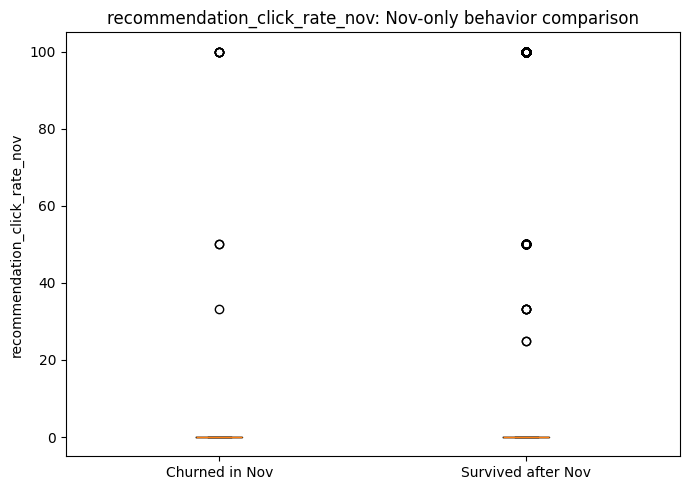

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\795382180.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


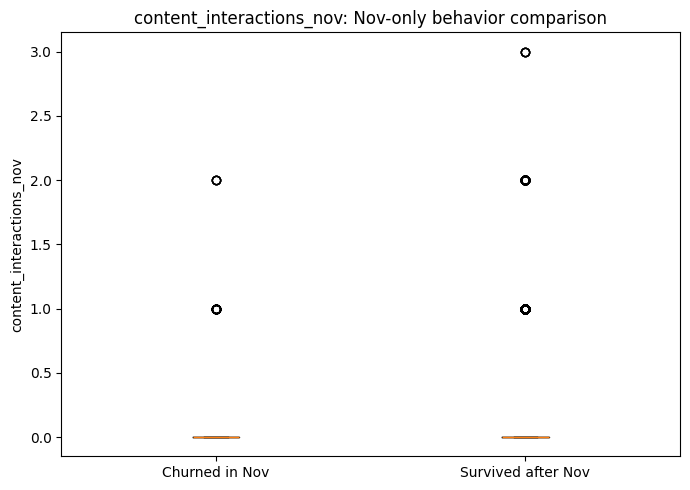

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\795382180.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


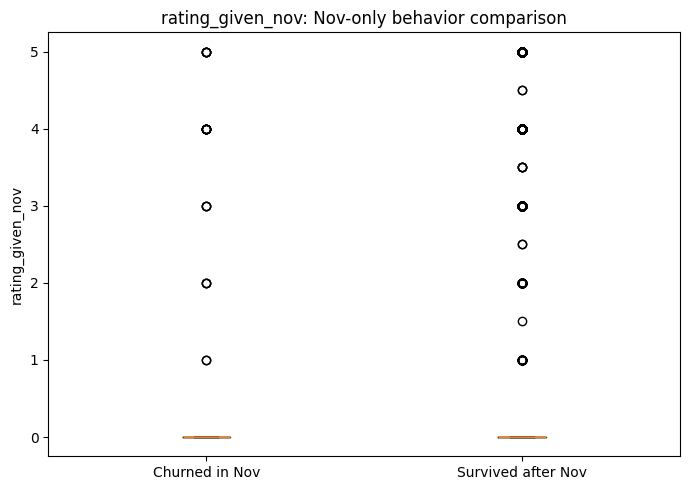

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\795382180.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


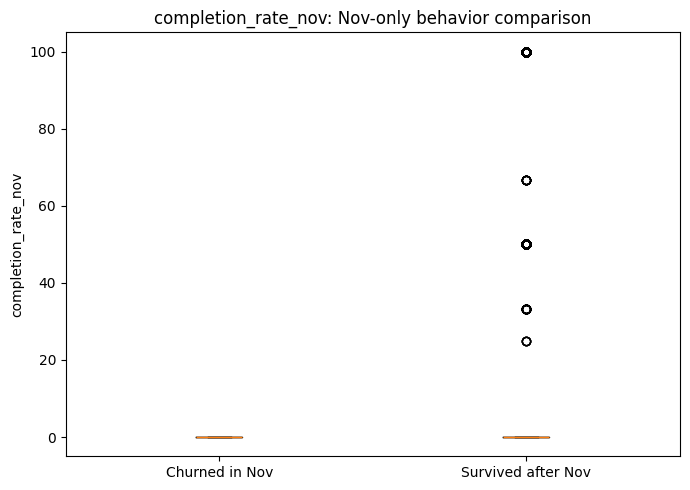

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\795382180.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


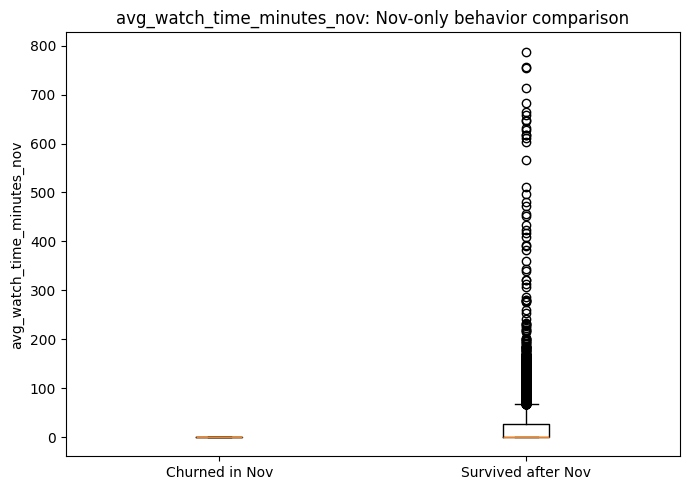

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\795382180.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


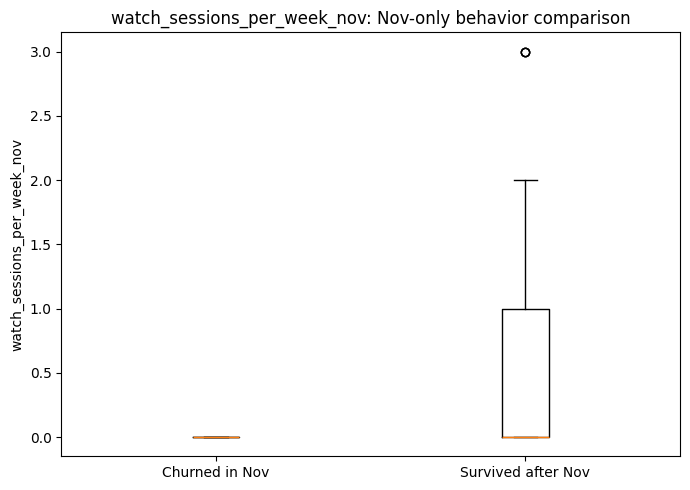

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\795382180.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


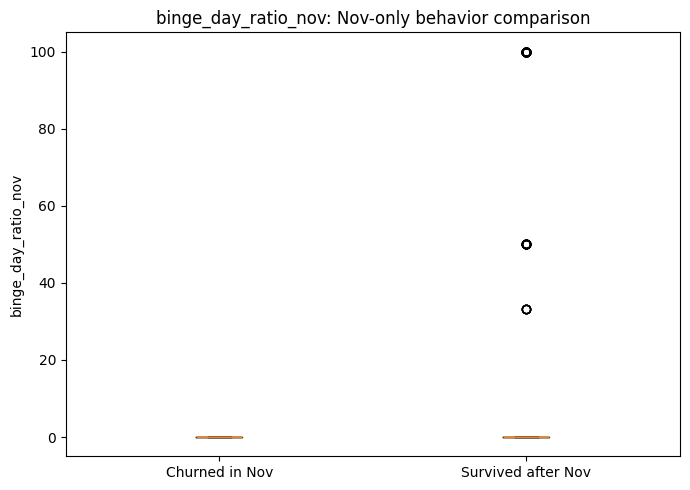

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\795382180.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


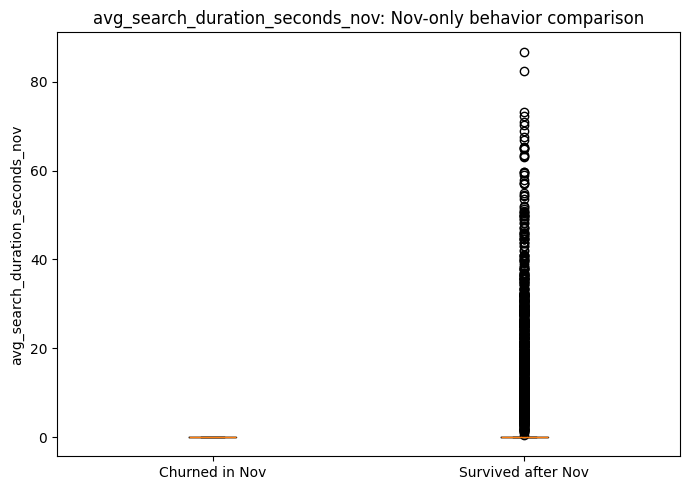

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\795382180.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


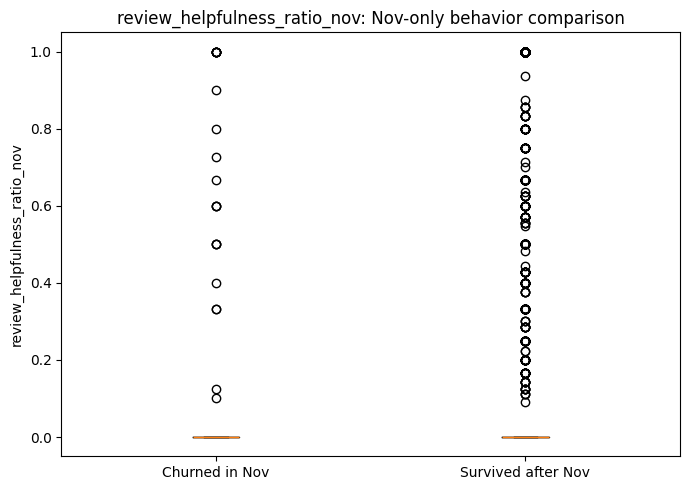

In [28]:
import matplotlib.pyplot as plt

# =================================================
# [비교할 11월 행동 컬럼]
# =================================================
behavior_cols = [
    'recommendation_click_rate_nov',
    'content_interactions_nov',
    'rating_given_nov',
    'completion_rate_nov',
    'avg_watch_time_minutes_nov',
    'watch_sessions_per_week_nov',
    'binge_day_ratio_nov',
    'avg_search_duration_seconds_nov',
    'review_helpfulness_ratio_nov'
]

# =================================================
# [boxplot]
# 11월에 탈퇴한 사람 vs 11월 이후에도 남아있는 사람
# =================================================
for col in behavior_cols:

    churned_values = analysis_df.loc[
        analysis_df['nov_group'] == 'Churned in Nov',
        col
    ].dropna()

    survived_values = analysis_df.loc[
        analysis_df['nov_group'] == 'Survived after Nov',
        col
    ].dropna()

    plt.figure(figsize=(7, 5))
    plt.boxplot(
        [churned_values, survived_values],
        labels=['Churned in Nov', 'Survived after Nov']
    )

    plt.ylabel(col)
    plt.title(f'{col}: Nov-only behavior comparison')
    plt.tight_layout()
    plt.show()

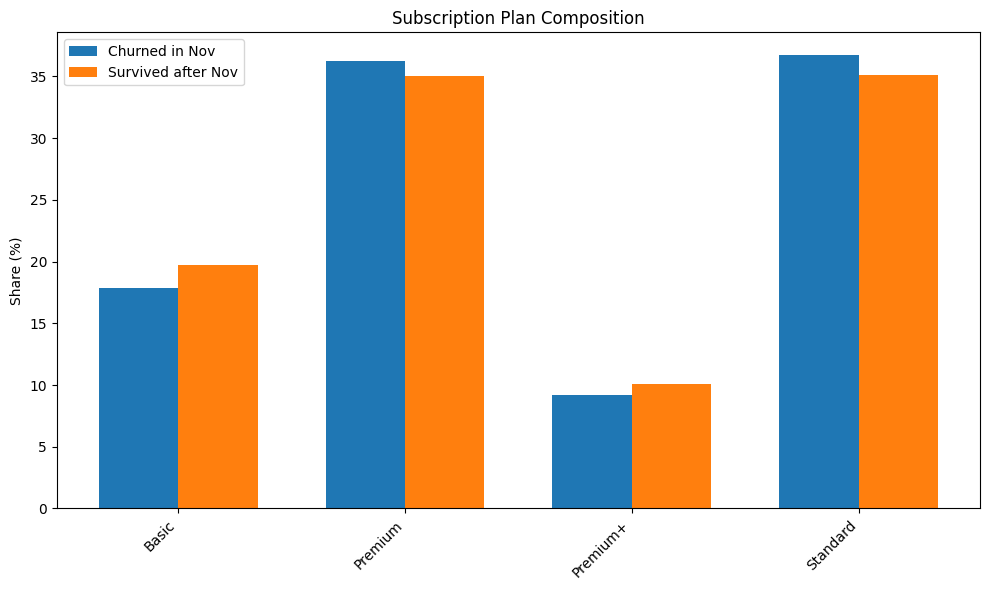

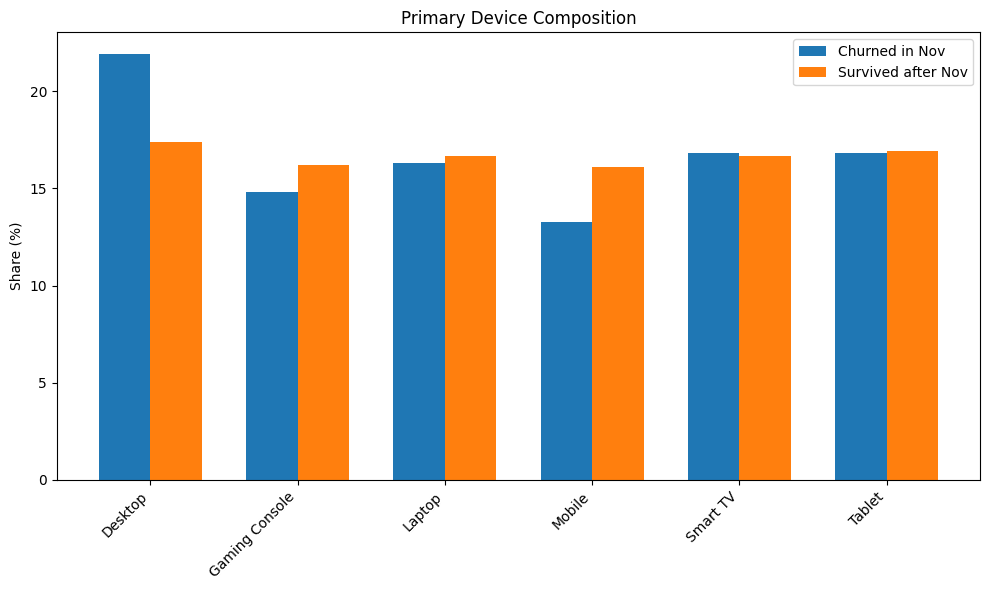

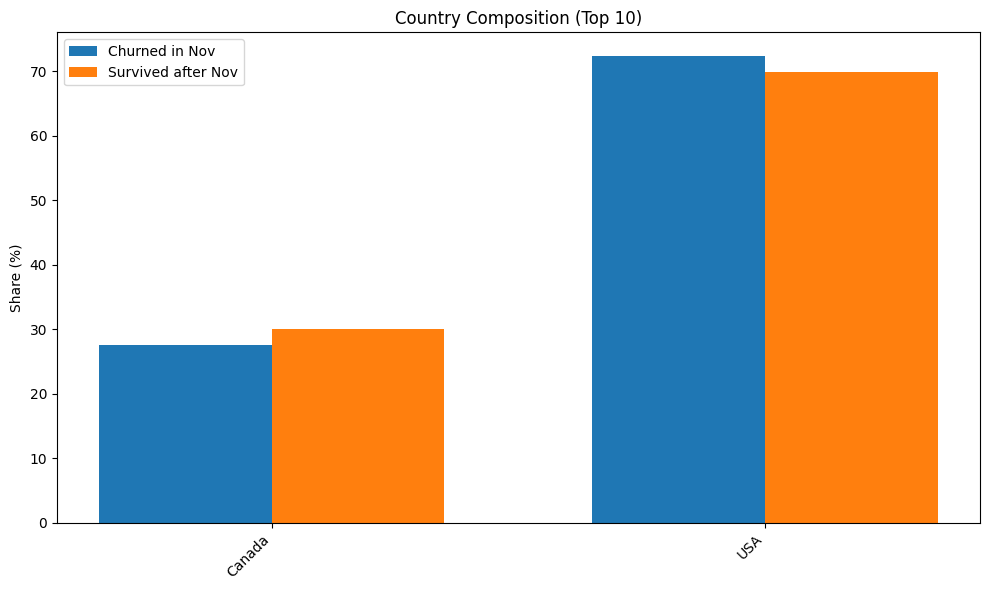

C:\Users\Playdata\AppData\Local\Temp\ipykernel_47668\2129650636.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(['nov_group', category_col])['user_id']


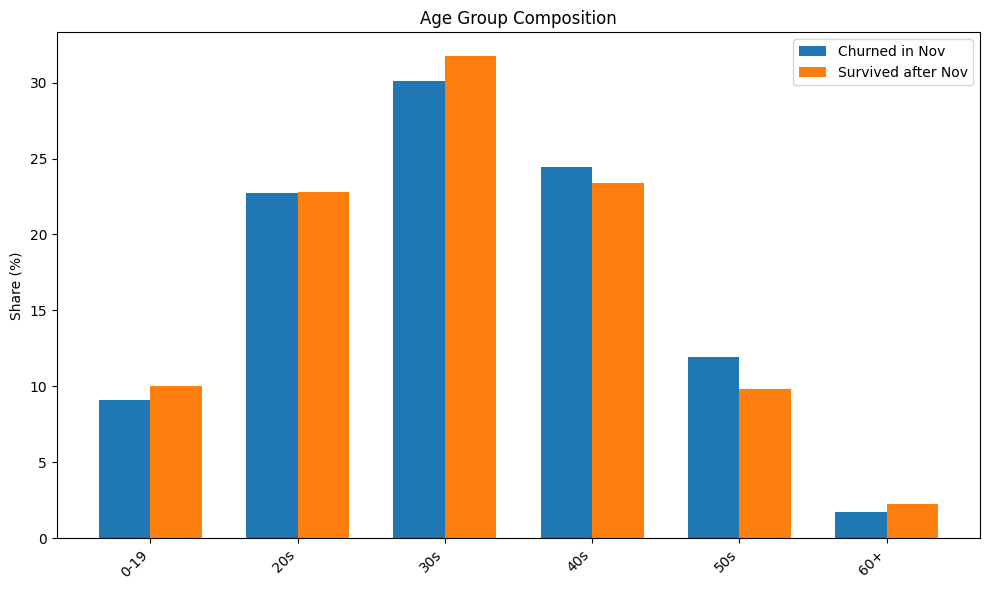

nov_group,Churned in Nov,Survived after Nov
age_group,,
0-19,0.090909,0.100202
20s,0.227273,0.227829
30s,0.301136,0.317227
40s,0.244318,0.234002
50s,0.119318,0.098421
60+,0.017045,0.022320


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================
# 연령대는 임시로만 생성
# =================================================
segment_df = analysis_df.copy()

segment_df['age_group'] = pd.cut(
    segment_df['age'],
    bins=[0, 19, 29, 39, 49, 59, 200],
    labels=['0-19', '20s', '30s', '40s', '50s', '60+'],
    right=True
)

def plot_segment_share(data, category_col, title, top_n=None):
    temp = data.copy()

    count_table = (
        temp.groupby(['nov_group', category_col])['user_id']
        .count()
        .reset_index(name='user_count')
    )

    if top_n is not None:
        top_categories = (
            count_table.groupby(category_col)['user_count']
            .sum()
            .sort_values(ascending=False)
            .head(top_n)
            .index
        )
        count_table = count_table[count_table[category_col].isin(top_categories)].copy()

    count_table['share'] = (
        count_table['user_count']
        / count_table.groupby('nov_group')['user_count'].transform('sum')
    )

    pivot_table = (
        count_table.pivot(index=category_col, columns='nov_group', values='share')
        .fillna(0)
    )

    expected_cols = ['Churned in Nov', 'Survived after Nov']
    for c in expected_cols:
        if c not in pivot_table.columns:
            pivot_table[c] = 0
    pivot_table = pivot_table[expected_cols]

    x = np.arange(len(pivot_table))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, pivot_table['Churned in Nov'] * 100, width=width, label='Churned in Nov')
    plt.bar(x + width/2, pivot_table['Survived after Nov'] * 100, width=width, label='Survived after Nov')

    plt.xticks(x, pivot_table.index.astype(str), rotation=45, ha='right')
    plt.ylabel('Share (%)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return pivot_table

# 구독 플랜
plot_segment_share(segment_df, 'subscription_plan', 'Subscription Plan Composition')

# 디바이스
plot_segment_share(segment_df, 'primary_device', 'Primary Device Composition')

# 국가 (상위 10개만)
plot_segment_share(segment_df, 'country', 'Country Composition (Top 10)', top_n=10)

# 연령대
plot_segment_share(segment_df, 'age_group', 'Age Group Composition')

c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({
c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({
c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:364: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future ve

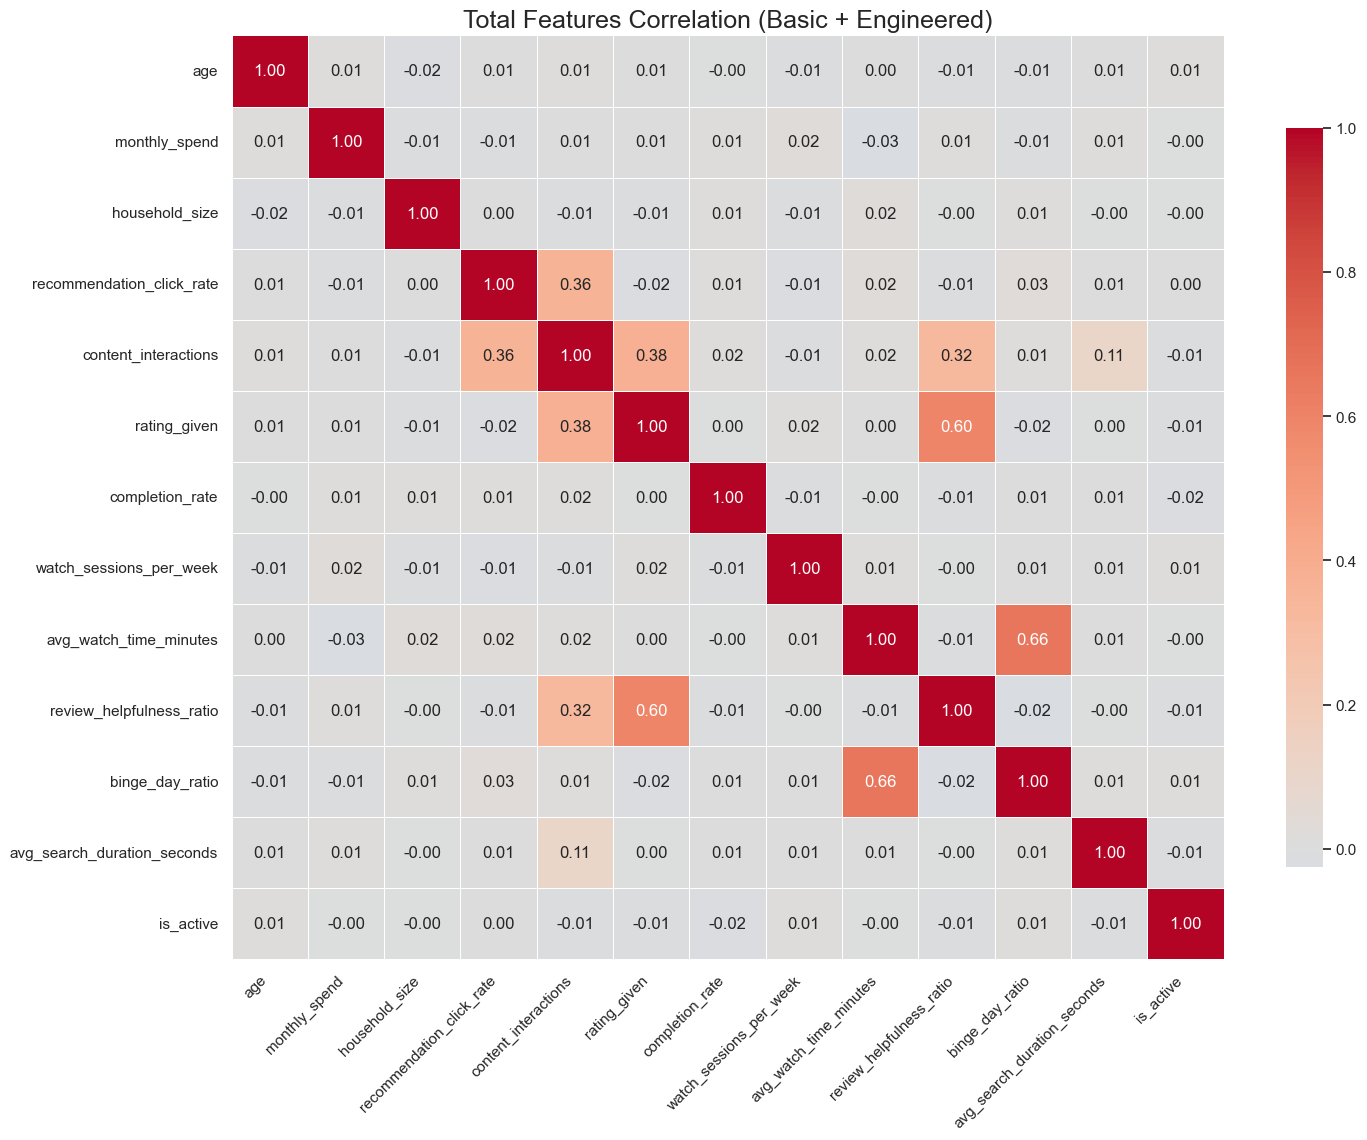

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 피처 생성 (모든 메서드 실행)
builder = NetflixFeatureBuilder(user, watch, reviews, rec_logs, search_logs, movies)
final_df = (
    builder.add_recommendation_click_rate()
           .add_content_interactions()
           .add_rating_given()
           .add_completion_rate()
           .add_watch_sessions_per_week()
           .add_avg_watch_time_minutes()
           .add_favorite_genre()
           .add_last_activity_date()
           .add_review_helpfulness_ratio()
           .add_binge_day_ratio()
           .add_avg_search_duration_seconds()
           .get_data()
)

# 2. 상관관계 분석용 데이터 필터링
# 기본 user 테이블의 is_active나 연령대 등 수치형 데이터가 자동으로 포함됩니다.
# 날짜와 ID, 문자열만 수동으로 제외해 주세요.
exclude_keywords = ['id', 'date', 'genre', 'name', 'email'] # 제외할 키워드들
cols_to_drop = [col for col in final_df.columns if any(key in col.lower() for key in exclude_keywords)]

# 수치형 데이터만 선택하되, 위에서 정의한 제외 컬럼들 제거
numeric_df = final_df.select_dtypes(include=[np.number]).drop(columns=cols_to_drop, errors='ignore')

# 만약 is_active가 True/False(불리언) 형태라면 숫자로 바꿔줘야 히트맵에 나옵니다.
if 'is_active' in final_df.columns and final_df['is_active'].dtype == 'bool':
    numeric_df['is_active'] = final_df['is_active'].astype(int)

# 3. 히트맵 출력
plt.figure(figsize=(16, 12))
sns.set_theme(style="white")

corr = numeric_df.corr()

# 상관관계 시각화
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Total Features Correlation (Basic + Engineered)', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.show()

In [31]:
import os

save_path = r'C:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\new_user.csv'

new_user = builder.get_data()
new_user.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"저장 완료: {save_path}")

저장 완료: C:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\new_user.csv


In [32]:
new_user.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         10000 non-null  object 
 1   email                           10000 non-null  object 
 2   first_name                      10000 non-null  object 
 3   last_name                       10000 non-null  object 
 4   age                             8806 non-null   float64
 5   gender                          9200 non-null   object 
 6   country                         10000 non-null  object 
 7   state_province                  10000 non-null  object 
 8   city                            10000 non-null  object 
 9   subscription_plan               10000 non-null  object 
 10  subscription_start_date         10000 non-null  object 
 11  is_active                       10000 non-null  bool   
 12  monthly_spend                   9007 n